# Harry potter discovery
#### Progetto per l'insegnamento di Data Analytics dell'anno accademico 2024/2025.
#### Componenti: Alessia Novacco 918850, Nicolò Sansevrino 865889

Il progetto verte su ....

In [379]:
import kagglehub
import pandas as pd
import numpy as np
import scipy
import re
import csv
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from collections import Counter
from nltk.corpus import stopwords
import nltk
from transformers import RobertaTokenizer, TFRobertaModel, TFAutoModelForSequenceClassification
import tensorflow as tf
from tqdm import tqdm


In [380]:
characters = pd.read_csv("Harry_Potter_Movies/Characters.csv", encoding='latin-1')
characters.head()

,Character ID,Character Name,Species,Gender,House,Patronus,Wand (Wood),Wand (Core)
0,1,Harry Potter,Human,Male,Gryffindor,Stag,Holly,Phoenix Feather
1,2,Ron Weasley,Human,Male,Gryffindor,Jack Russell Terrier,NaN,NaN
2,3,Hermione Granger,Human,Female,Gryffindor,Otter,Vine,Dragon Heartstring
3,4,Albus Dumbledore,Human,Male,Gryffindor,Phoenix,Elder,Thestral Tail Hair
4,5,Rubeus Hagrid,Half-Human/Half-Giant,Male,Gryffindor,NaN,Oak,NaN


In [381]:
movies = pd.read_csv("Harry_Potter_Movies/Movies.csv", encoding="utf-8-sig")
movies.head(9)

,Movie ID,Movie Title,Release Year,Runtime,Budget,Box Office
0,1,Harry Potter and the Philosopher's Stone,2001,152,"$125,000,000","$1,002,000,000"
1,2,Harry Potter and the Chamber of Secrets,2002,161,"$100,000,000","$880,300,000"
2,3,Harry Potter and the Prisoner of Azkaban,2004,142,"$130,000,000","$796,700,000"
3,4,Harry Potter and the Goblet of Fire,2005,157,"$150,000,000","$896,400,000"
4,5,Harry Potter and the Order of the Phoenix,2007,138,"$150,000,000","$942,000,000"
5,6,Harry Potter and the Half-Blood Prince,2009,153,"$250,000,000","$943,200,000"
6,7,Harry Potter and the Deathly Hallows Part 1,2010,146,"$200,000,000","$976,900,000"
7,8,Harry Potter and the Deathly Hallows Part 2,2011,130,"$250,000,000","$1,342,000,000"


In [382]:
dialogues = pd.read_csv("Harry_Potter_Movies/Dialogue.csv", encoding='latin-1')
dialogues.head()

,Dialogue ID,Chapter ID,Place ID,Character ID,Dialogue
0,1,1,8,4,I should have known that you would be here...P...
1,2,1,8,7,"Good evening, Professor Dumbledore. Are the ru..."
2,3,1,8,4,"I'm afraid so, Professor. The good, and the bad."
3,4,1,8,7,And the boy?
4,5,1,8,4,Hagrid is bringing him.


In [383]:
chapters = pd.read_csv("Harry_Potter_Movies/Chapters.csv", encoding='latin-1')
chapters.head()

,Chapter ID,Chapter Name,Movie ID,Movie Chapter
0,1,Doorstep Delivery,1,1
1,2,The Vanishing Glass,1,2
2,3,Letters from No One,1,3
3,4,Keeper of the Keys,1,4
4,5,Diagon Alley,1,5


In [384]:
dialogs = dialogues.merge(chapters[["Chapter ID", "Movie ID"]], on="Chapter ID")
dialogs = dialogs.sort_values(by=["Movie ID", "Chapter ID", "Dialogue ID"])
dialogs.head()

,Dialogue ID,Chapter ID,Place ID,Character ID,Dialogue,Movie ID
0,1,1,8,4,I should have known that you would be here...P...,1
1,2,1,8,7,"Good evening, Professor Dumbledore. Are the ru...",1
2,3,1,8,4,"I'm afraid so, Professor. The good, and the bad.",1
3,4,1,8,7,And the boy?,1
4,5,1,8,4,Hagrid is bringing him.,1


In [385]:
# Aggiungi Character Name
dialogs = dialogs.merge(characters[["Character ID", "Character Name"]], on="Character ID")
dialogs["speaker"] = dialogs["Character Name"].str.lower().str.strip()
dialogs.head()

,Dialogue ID,Chapter ID,Place ID,Character ID,Dialogue,Movie ID,Character Name,speaker
0,1,1,8,4,I should have known that you would be here...P...,1,Albus Dumbledore,albus dumbledore
1,2,1,8,7,"Good evening, Professor Dumbledore. Are the ru...",1,Minerva McGonagall,minerva mcgonagall
2,3,1,8,4,"I'm afraid so, Professor. The good, and the bad.",1,Albus Dumbledore,albus dumbledore
3,4,1,8,7,And the boy?,1,Minerva McGonagall,minerva mcgonagall
4,5,1,8,4,Hagrid is bringing him.,1,Albus Dumbledore,albus dumbledore


Dopo un esplorazione manuale del dataset abbiamo osservato che esistono entità trattate come personaggi, ma che di fatto non hanno alcuna valenza, perciò si è provveduto a rimuoverli.

In [386]:
graphs = {}  # film_id → grafo
centrality_results = {}  # film_id → df con centralità

for mid, g in dialogs.groupby("Movie ID"):

    G = nx.DiGraph()

    # Lista dei turni parlati
    speakers = g["Character Name"].tolist()

    # Costruisci coppie consecutive A→B
    pairs = [(a, b) for a, b in zip(speakers[:-1], speakers[1:]) if a != b]

    # Conta interazioni tra ogni coppia
    interaction_count = defaultdict(int)
    interlocutors = defaultdict(set)

    for a, b in pairs:
        interaction_count[(a, b)] += 1
        interlocutors[a].add(b)

    max_count = max(interaction_count.values())

    # Calcola somma delle interazioni per ogni A (normalizzazione per A)
    for (a, b), count in interaction_count.items():
        norm_weight = count / max_count
        G.add_edge(a, b, weight=norm_weight)


    graphs[mid] = G

    betweenness = nx.betweenness_centrality(G, weight="weight")

    #  Calcolo degree centrality su grafo non orientato temporaneo
    G_undirected = G.to_undirected()
    degree = nx.degree_centrality(G_undirected)

    # Crea DataFrame centralità
    df_centrality = pd.DataFrame({
        'Character Name': list(betweenness.keys()),
        'Betweenness': [betweenness[k] for k in betweenness.keys()],
        'Centrality': [degree[k] for k in betweenness.keys()],
        'Movie ID': mid
    })

    centrality_results[mid] = df_centrality

    # OUTPUT DI CONTROLLO
    print(f"Movie ID {mid} - Nodi: {G.number_of_nodes()}, Archi: {G.number_of_edges()}")
    display(df_centrality.sort_values("Betweenness", ascending=False).head(10))

    centrality_all = pd.concat(centrality_results, ignore_index=True)

    # Elimina le colonne che causano conflitto PRIMA del merge
    dialogs = dialogs.drop(columns=['Centrality', 'Betweenness'], errors='ignore')

    # Ora puoi eseguire il merge tranquillamente
    dialogs = dialogs.merge(centrality_all, on=['Movie ID', 'Character Name'], how='left')

Movie ID 1 - Nodi: 50, Archi: 231


,Character Name,Betweenness,Centrality,Movie ID
6,Harry Potter,0.345273,0.734694,1
2,Rubeus Hagrid,0.224328,0.408163,1
21,Ron Weasley,0.168609,0.408163,1
43,Lee Jordan,0.152056,0.163265,1
23,Hermione Granger,0.136764,0.346939,1
31,Girl,0.127722,0.204082,1
12,Boy,0.089449,0.163265,1
1,Minerva McGonagall,0.081923,0.285714,1
39,Argus Filch,0.073772,0.142857,1
0,Albus Dumbledore,0.070910,0.183673,1


Movie ID 2 - Nodi: 51, Archi: 257


,Character Name,Betweenness,Centrality,Movie ID
0,Harry Potter,0.269975,0.66,2
5,Ron Weasley,0.269841,0.56,2
17,Gilderoy Lockhart,0.161372,0.34,2
15,Hermione Granger,0.151411,0.40,2
18,Draco Malfoy,0.123738,0.32,2
12,Other,0.111129,0.18,2
26,Pomona Sprout,0.102159,0.12,2
23,Severus Snape,0.075395,0.18,2
3,Dudley Dursley,0.069154,0.10,2
24,Albus Dumbledore,0.058013,0.28,2


Movie ID 3 - Nodi: 40, Archi: 199


...

,Character Name,Betweenness,Centrality,Movie ID
10,Hermione Granger,0.299548,0.473684,6
4,Harry Potter,0.235784,0.631579,6
7,Ginny Weasley,0.202361,0.394737,6
15,Draco Malfoy,0.172478,0.315789,6
9,Ron Weasley,0.169443,0.447368,6
5,Albus Dumbledore,0.160812,0.315789,6
6,Horace Slughorn,0.144337,0.421053,6
14,Luna Lovegood,0.094123,0.184211,6
20,Minerva McGonagall,0.073735,0.210526,6
28,Neville Longbottom,0.073709,0.131579,6


Movie ID 7 - Nodi: 57, Archi: 233


,Character Name,Betweenness,Centrality,Movie ID
17,Harry Potter,0.343468,0.607143,7
2,Hermione Granger,0.310606,0.410714,7
6,Voldemort,0.248505,0.285714,7
27,Remus Lupin,0.125322,0.250000,7
4,Ron Weasley,0.117326,0.392857,7
13,Bellatrix Lestrange,0.103107,0.196429,7
42,Dobby,0.097935,0.142857,7
12,Pius Thicknesse,0.083927,0.089286,7
21,Alastor Moody,0.077948,0.142857,7
22,Kingsley Shacklebolt,0.075979,0.107143,7


Movie ID 8 - Nodi: 50, Archi: 173


,Character Name,Betweenness,Centrality,Movie ID
2,Harry Potter,0.537508,0.673469,8
4,Ron Weasley,0.229746,0.346939,8
19,Ginny Weasley,0.206786,0.244898,8
11,Voldemort,0.194696,0.285714,8
15,Seamus Finnigan,0.158539,0.102041,8
5,Hermione Granger,0.140211,0.285714,8
8,Bellatrix Lestrange,0.089531,0.183673,8
21,Severus Snape,0.080272,0.163265,8
36,Sybill Trelawney,0.064413,0.061224,8
14,Neville Longbottom,0.055127,0.204082,8


In [387]:
# Usa pesi per le centralità
degree_c = nx.degree_centrality(G)  # NON usa pesi (opzionale)
in_deg   = G.in_degree(weight="weight")
out_deg  = G.out_degree(weight="weight")
pagerank = nx.pagerank(G, weight="weight")

df_c = pd.DataFrame({
    "character": list(G.nodes),
    "in_degree": [in_deg[n] for n in G.nodes],
    "out_degree": [out_deg[n] for n in G.nodes],
    "pagerank": [pagerank[n] for n in G.nodes],
    "raw_degree": [degree_c[n] for n in G.nodes],
    "movie_id": mid
})

centrality_results[mid] = df_c

In [388]:
centrality_df = pd.concat(centrality_results.values(), ignore_index=True)

In [389]:
# Funzione per disegnare il grafo di un tuo film reale
def draw_film_graph_real(G, cut_threshold, pagerank=None, title="Grafo delle interazioni normalizzate tra personaggi"):
    # stampiamo il pesoo degli archi in ordine decrescente
    '''print("Edge weights (sorted):")
    edge_weights = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    for u, v, d in edge_weights:
        print(f"{u} → {v}: {d['weight']:.2f}")'''

    if pagerank is None:
        pagerank = nx.pagerank(G, weight='weight')

    pos = nx.spring_layout(G, seed=42, k=0.6)
    fig, ax = plt.subplots(figsize=(14, 10))


    node_sizes = [15000 * pagerank[n] for n in G.nodes()]
    edge_sizes = [20 * G[u][v]['weight'] for u, v in G.edges()]
    # impostiamo una edge size massima per evitare che le linee siano troppo spesse
    max_edge_size = 2
    edge_sizes = [min(size, max_edge_size) for size in edge_sizes]
    # Normalizziamo i colori dei nodi in base al pagerank
    node_colors = [pagerank[n] for n in G.nodes()]
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)} # pesi delle interazioni, per ora le conserviamo e basta
    # creiamo degli alfa per gli archi variabili in base al peso dell'arco in modo che siano =0.2 se il loro peso è sotto il threshold, altrimenti =1

    edge_alphas = [0.2 if G[u][v]['weight'] < cut_threshold else 1 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, cmap=plt.cm.plasma, alpha=0.9, edgecolors='black', ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_sizes, alpha=edge_alphas, arrows=True, edge_color='#012201', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black', ax=ax)
    #nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8, ax=ax)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Pagerank")

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # mostriamo edge_labels_df in ordine decrescente per peso
    edge_labels_df = pd.DataFrame(edge_labels.items(), columns=['Edge', 'Weight'])
    edge_labels_df = edge_labels_df.sort_values(by='Weight', ascending=False)
    #print("Edge labels (sorted by weight):")
    #print(edge_labels_df.head(10))


In [390]:

def draw_heatmap(adj_matrix, cut_threshold):
  plt.figure(figsize=(12, 10))
  mask = adj_matrix <= cut_threshold
  ax = sns.heatmap(adj_matrix, cmap="YlOrRd", linewidths=0.5, linecolor='gray', mask=mask, cbar=True)

  plt.title("Heatmap delle interazioni tra personaggi")
  plt.xlabel("Personaggio")
  plt.ylabel("Personaggio")

  # grassetto per nomi asse X
  for i, label in enumerate(ax.get_xticklabels()):
      name = adj_matrix.columns[i]
      if (adj_matrix.iloc[:, i] > cut_threshold).any():
          label.set_fontweight('bold')
      label.set_text(name)
      label.set_rotation(90)

  # grassetto per nomi asse Y
  for i, label in enumerate(ax.get_yticklabels()):
      name = adj_matrix.index[i]
      if (adj_matrix.iloc[i, :] > cut_threshold).any():
          label.set_fontweight('bold')
      label.set_text(name)
      label.set_rotation(0)

  # Aggiunta bordi spessi per celle con valore > cut_threshold
  for i in range(adj_matrix.shape[0]):
      for j in range(adj_matrix.shape[1]):
          value = adj_matrix.iloc[i, j]
          if value > cut_threshold:
              # disegna un rettangolo con bordo spesso intorno alla cella
              ax.add_patch(plt.Rectangle(
                  (j, i), 1, 1, fill=False, edgecolor='black', lw=1))

  ax.set_xticklabels(ax.get_xticklabels())
  ax.set_yticklabels(ax.get_yticklabels())

  plt.tight_layout()
  plt.show()


In [391]:
def study_film(film_id, threshold):
  G = graphs[film_id]
  pagerank = nx.pagerank(G, weight="weight")  

  draw_film_graph_real(G, threshold, pagerank, title=f"Grafo delle interazioni normalizzate - Film {film_id}")

  betweenness = nx.betweenness_centrality(G, weight='weight')
  degree = nx.degree_centrality(G)

  adj_matrix = nx.to_pandas_adjacency(G, weight='weight')

  centrality_df = pd.DataFrame({
      "Character Name": list(G.nodes()),
      "Betweenness": [betweenness[n] for n in G.nodes()],
      "Degree": [degree[n] for n in G.nodes()]
  })

  draw_heatmap(adj_matrix, threshold)
  #print(centrality_df)

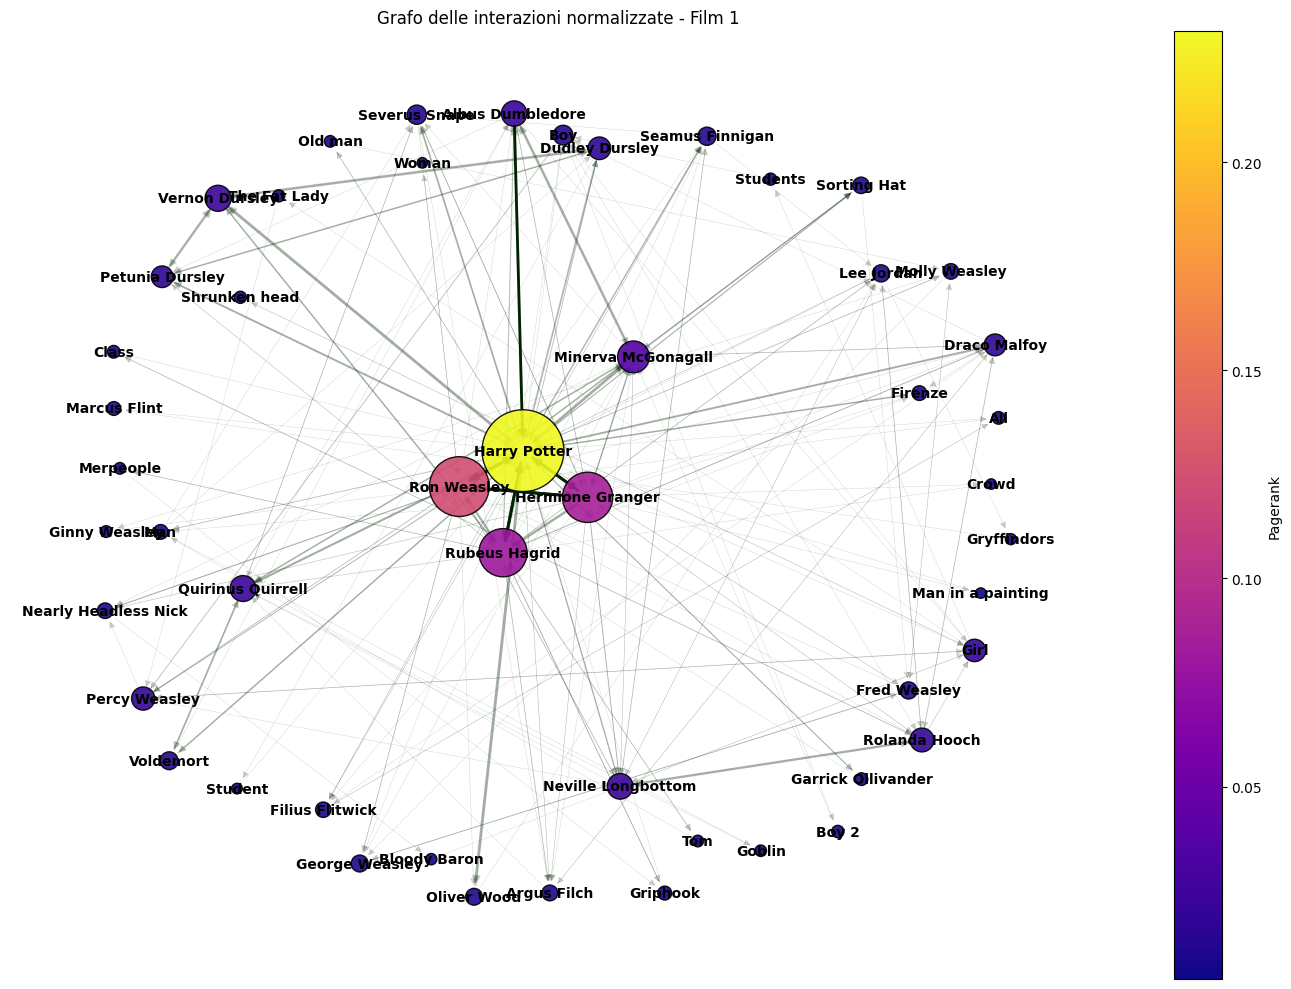

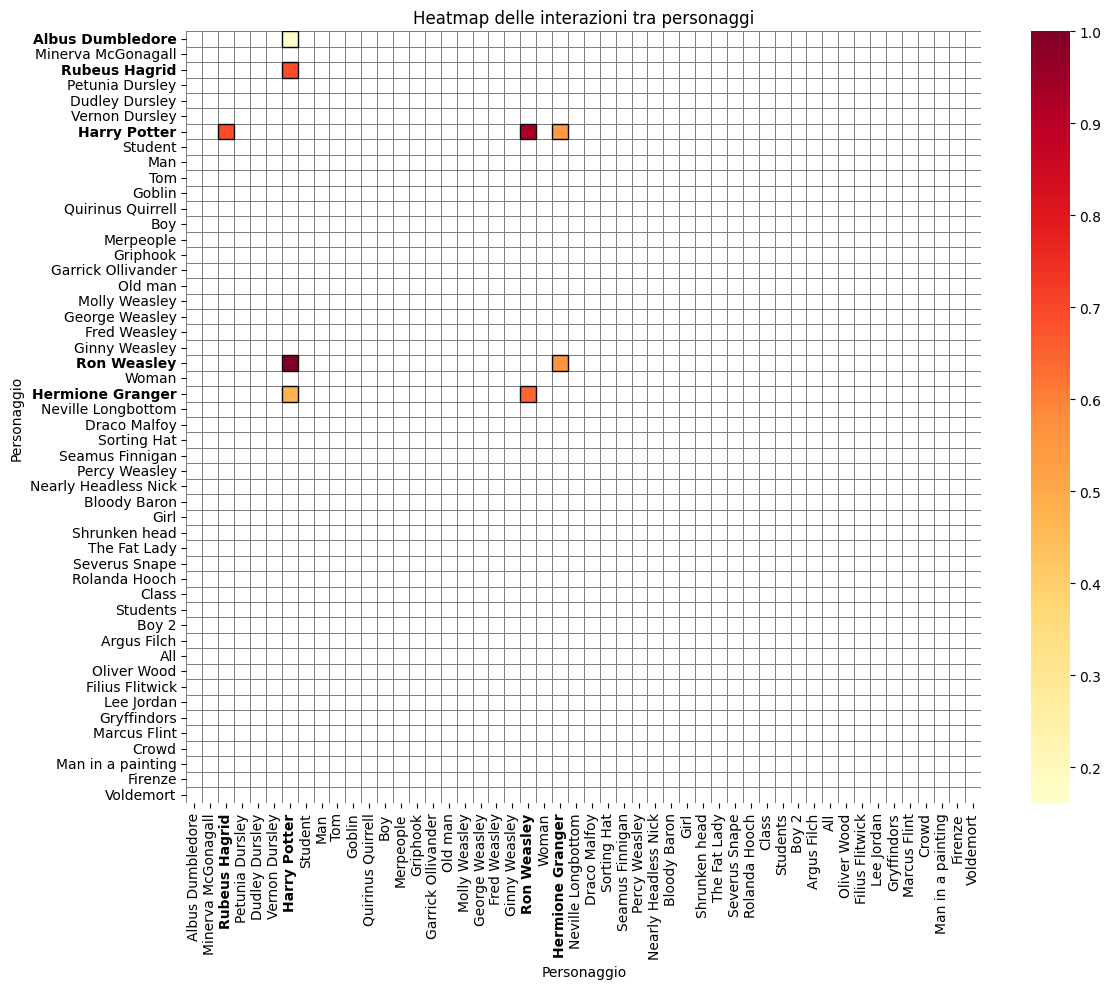

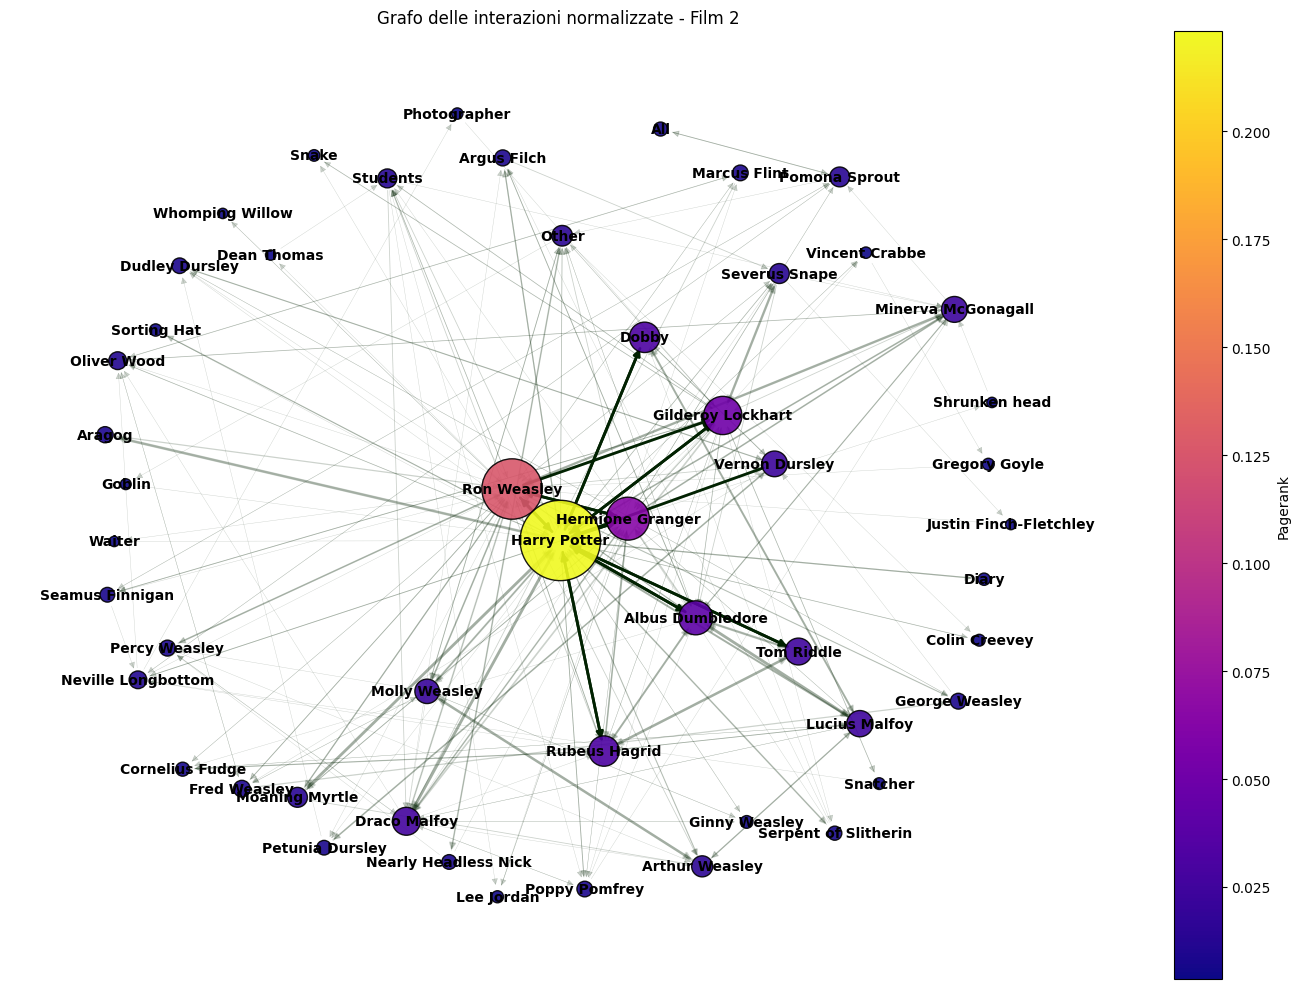

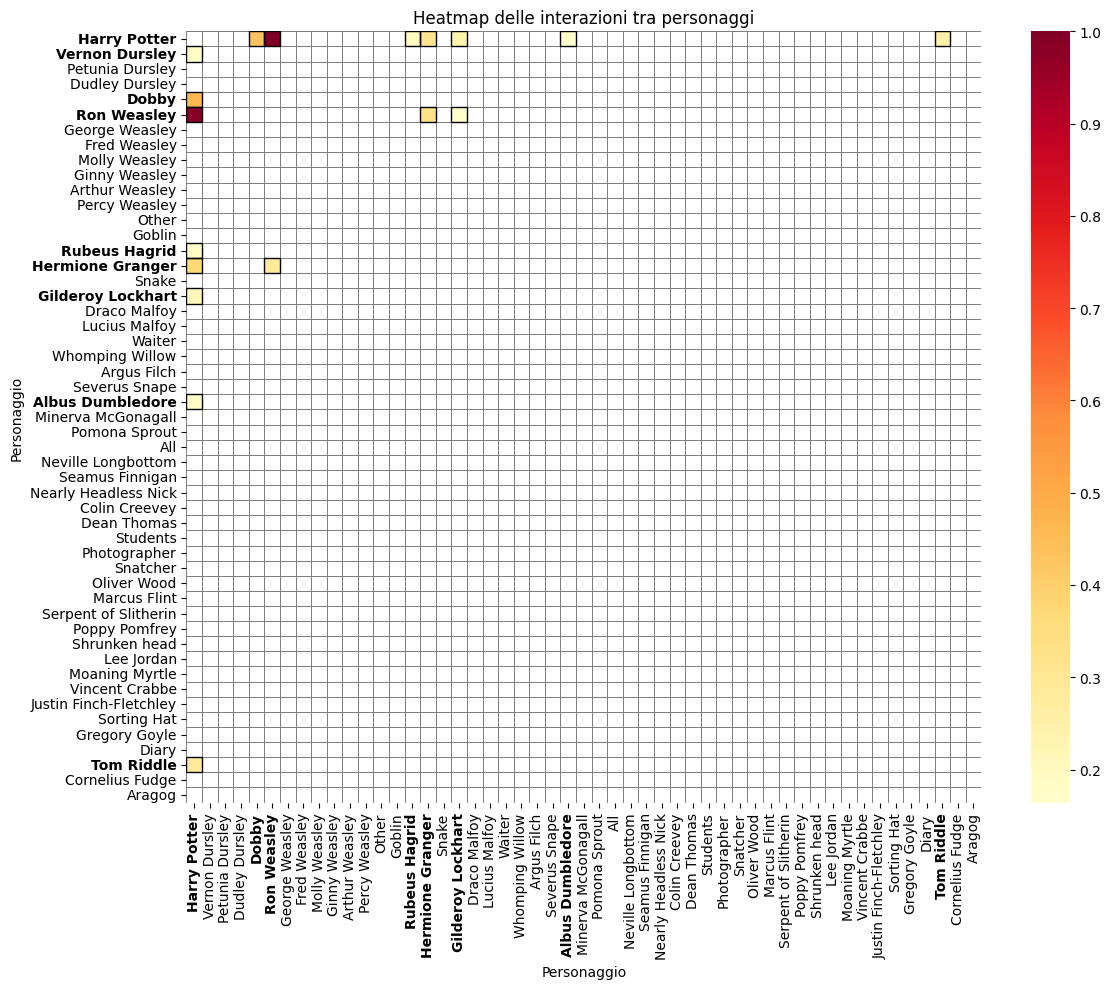

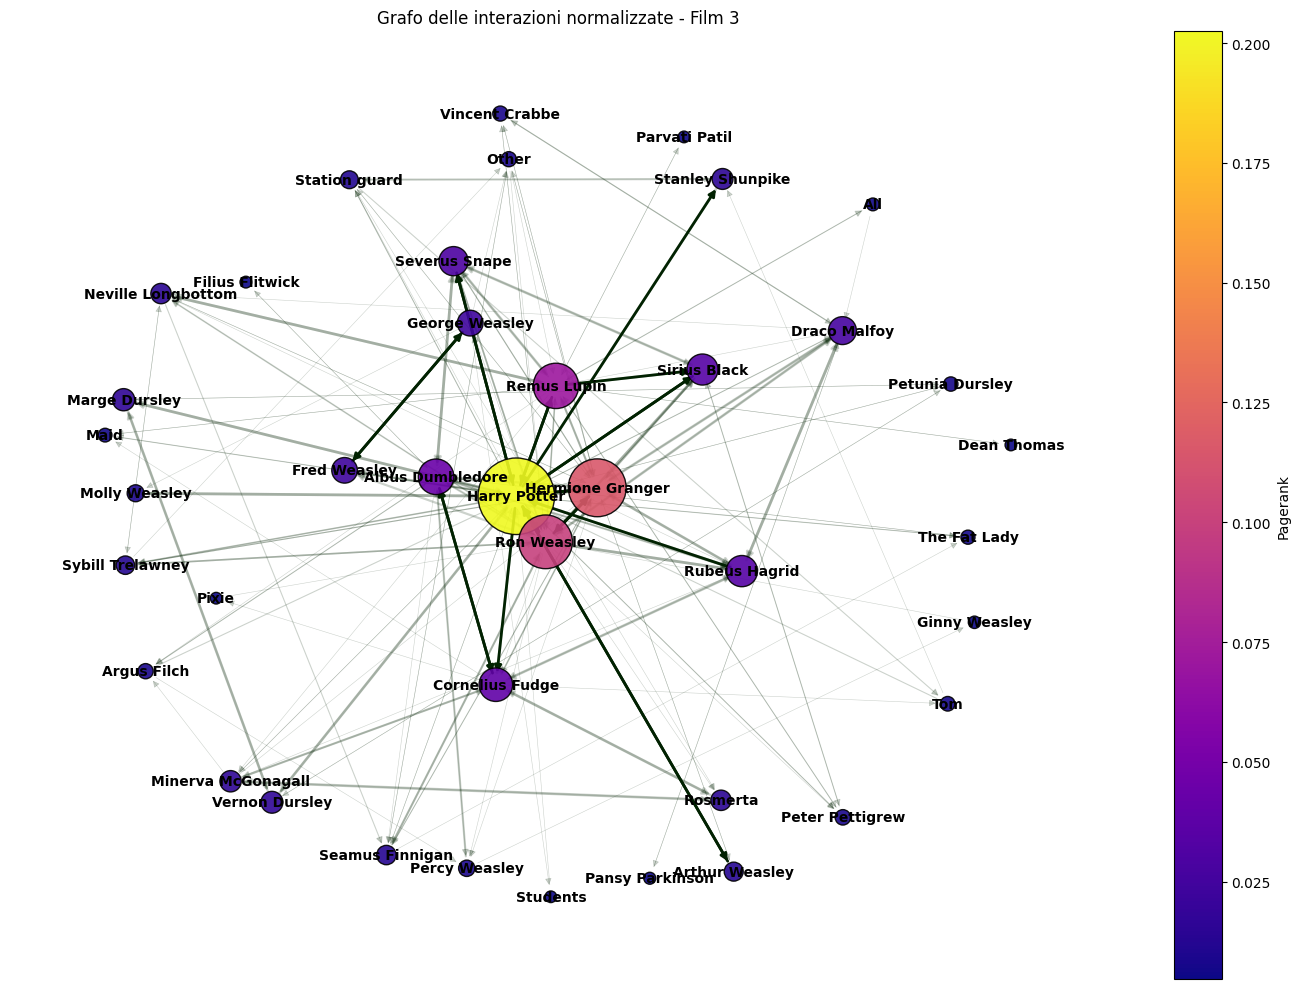

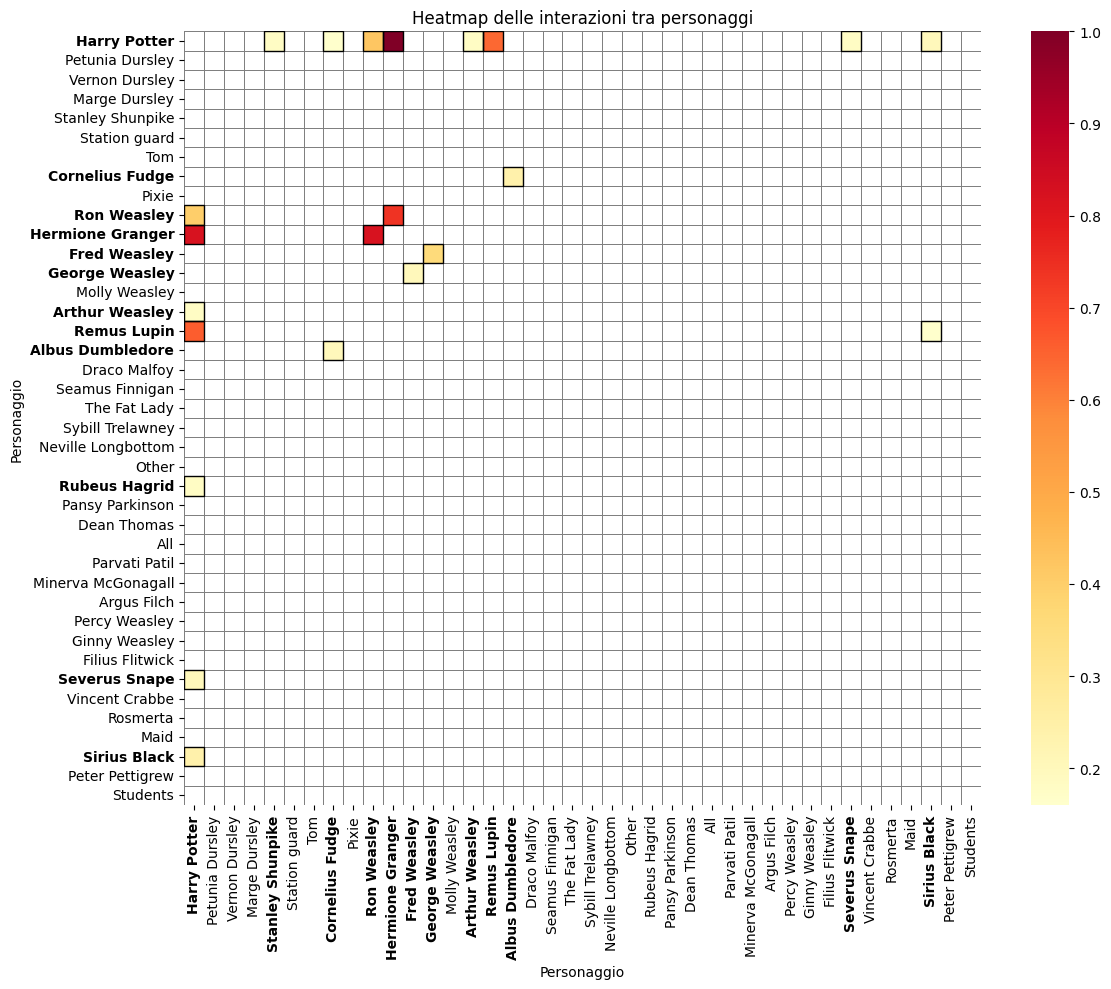

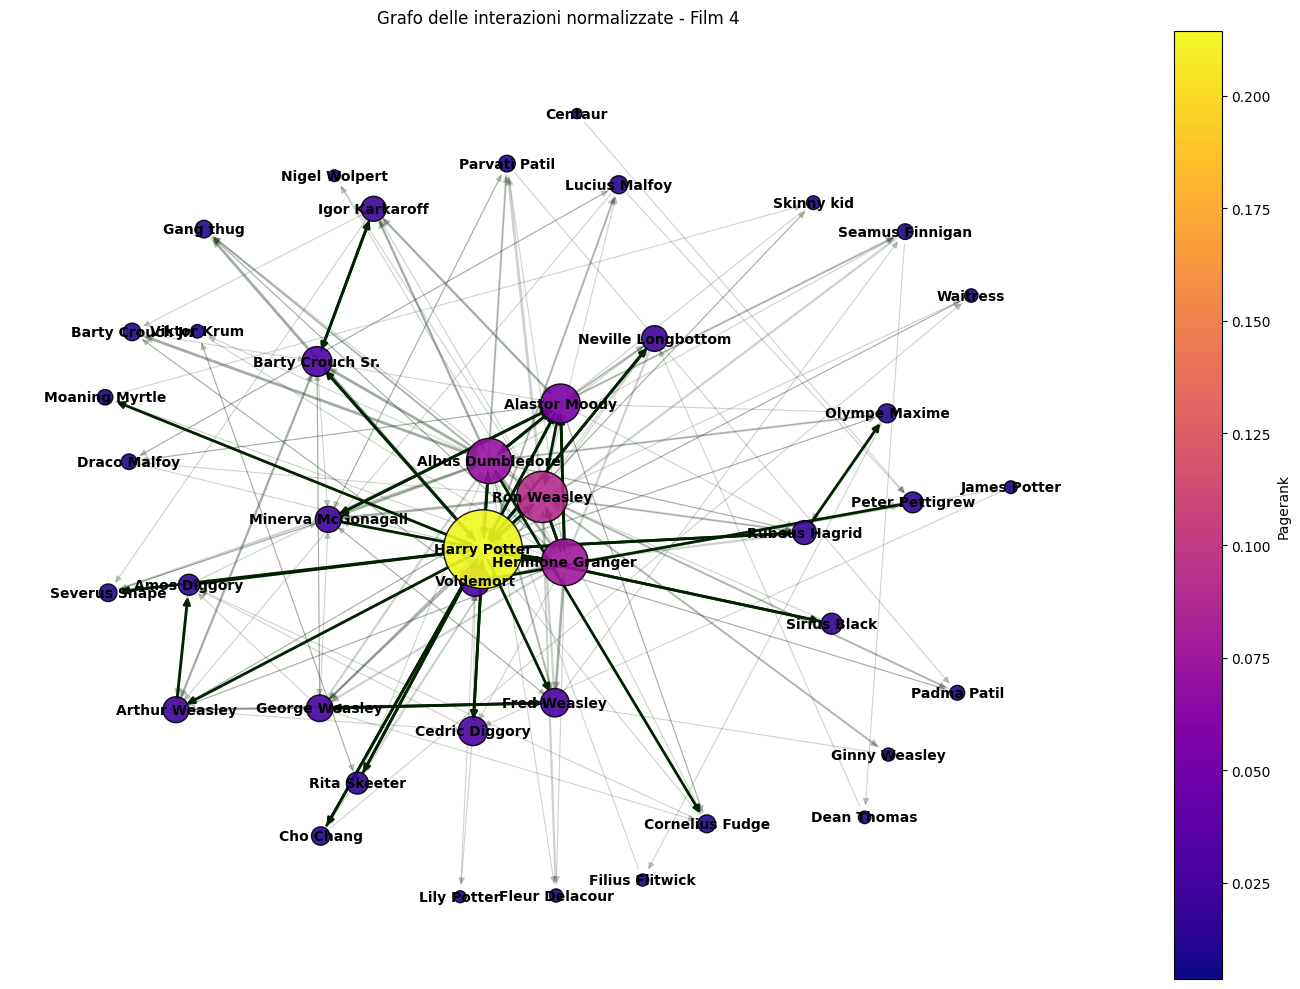

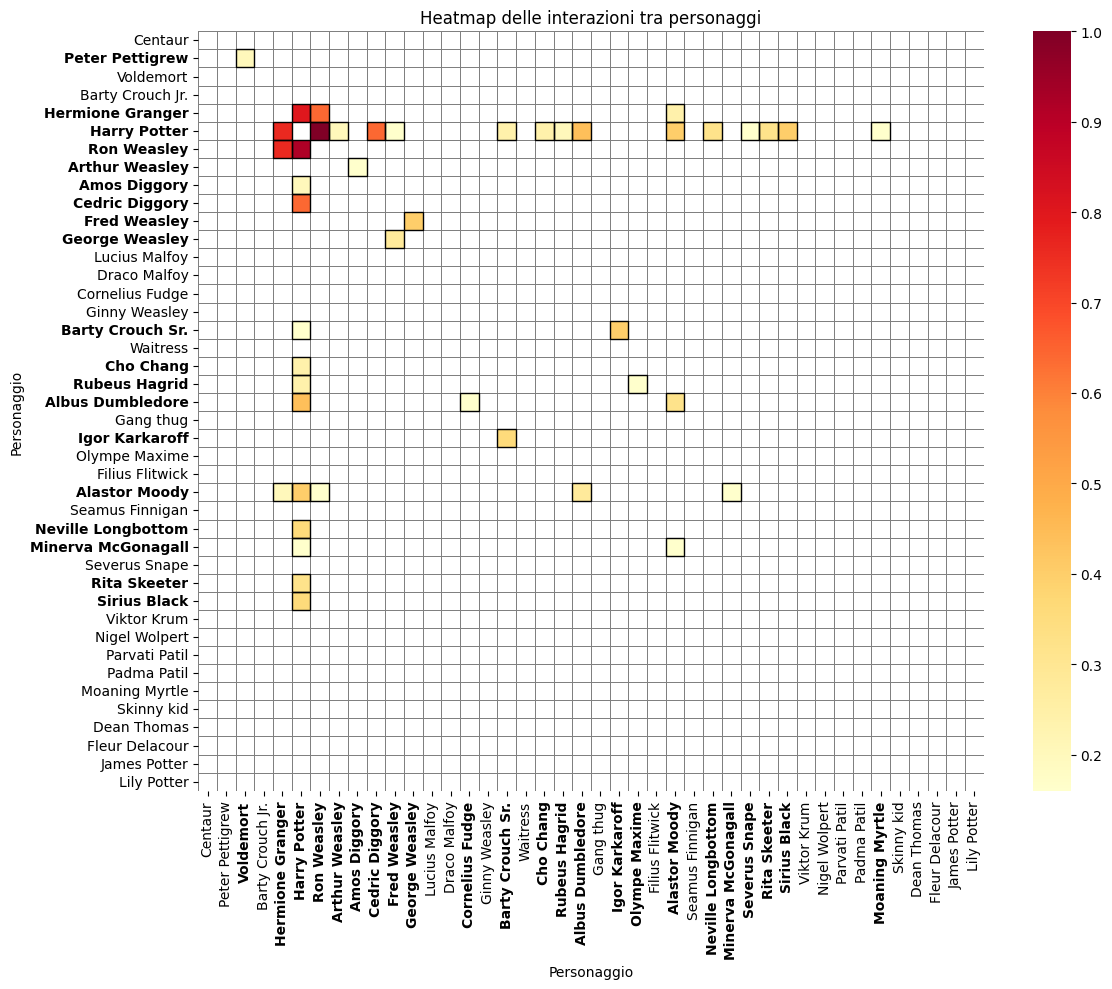

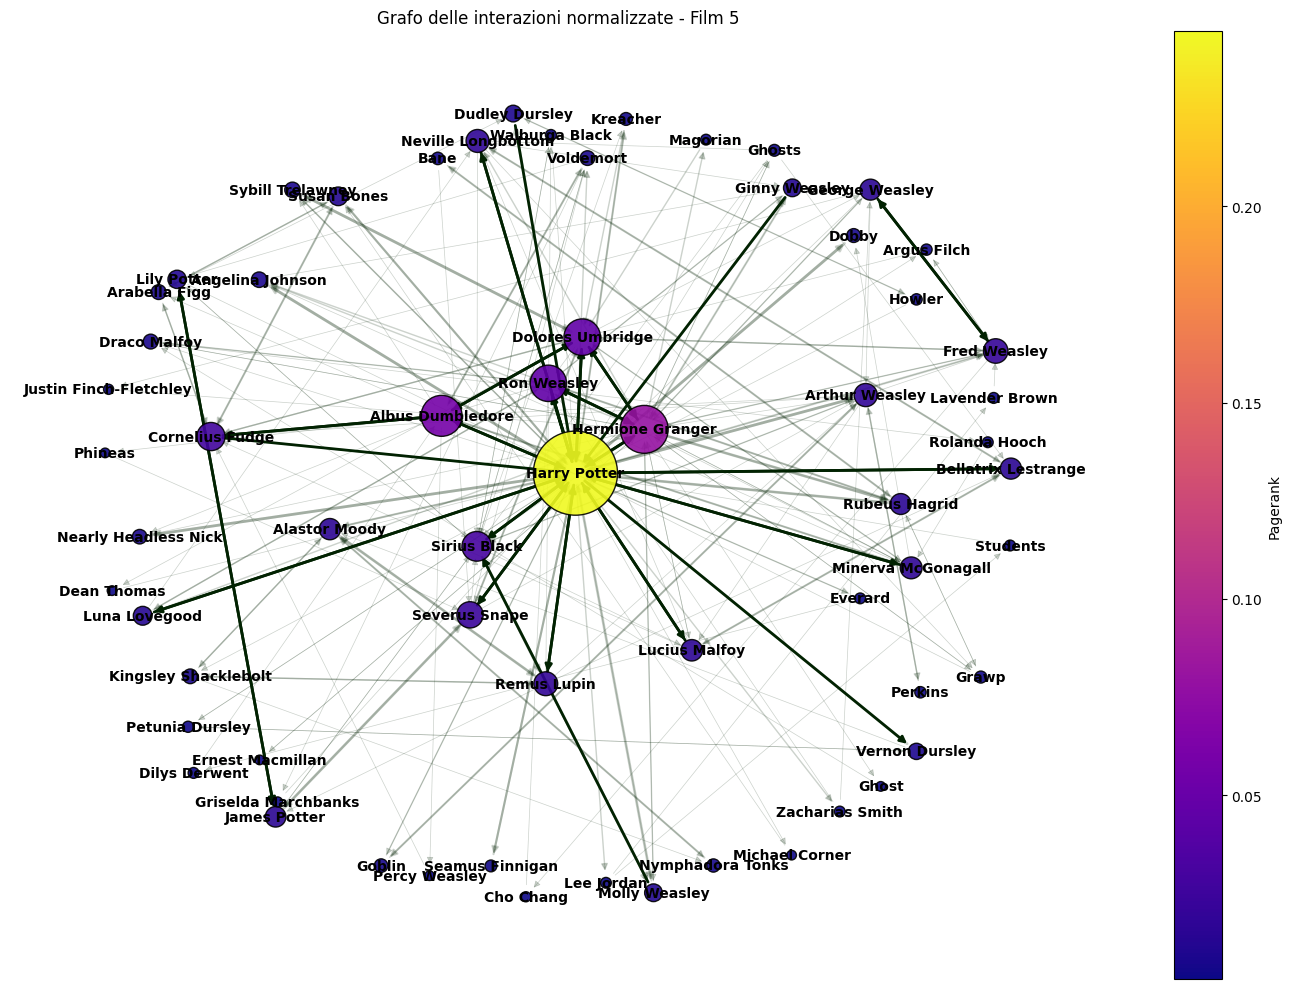

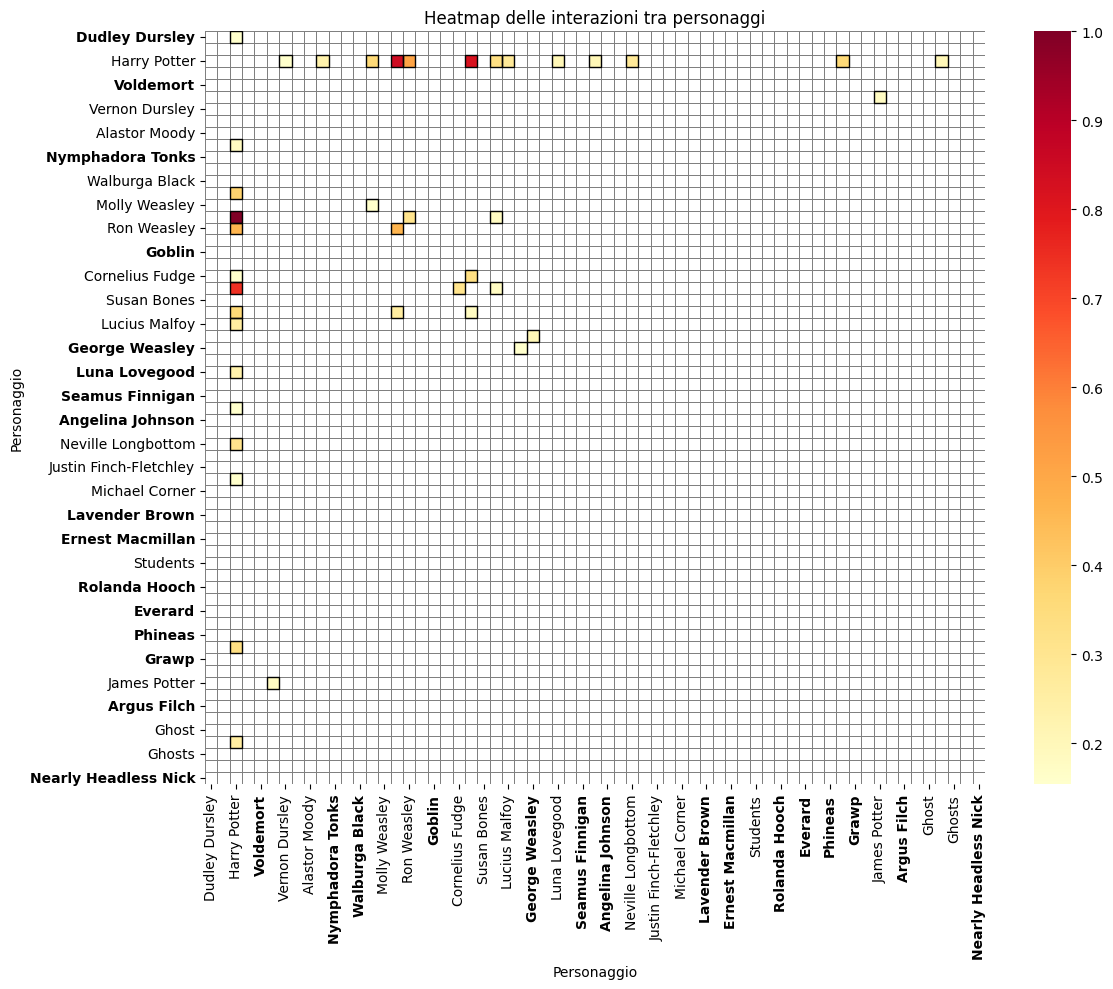

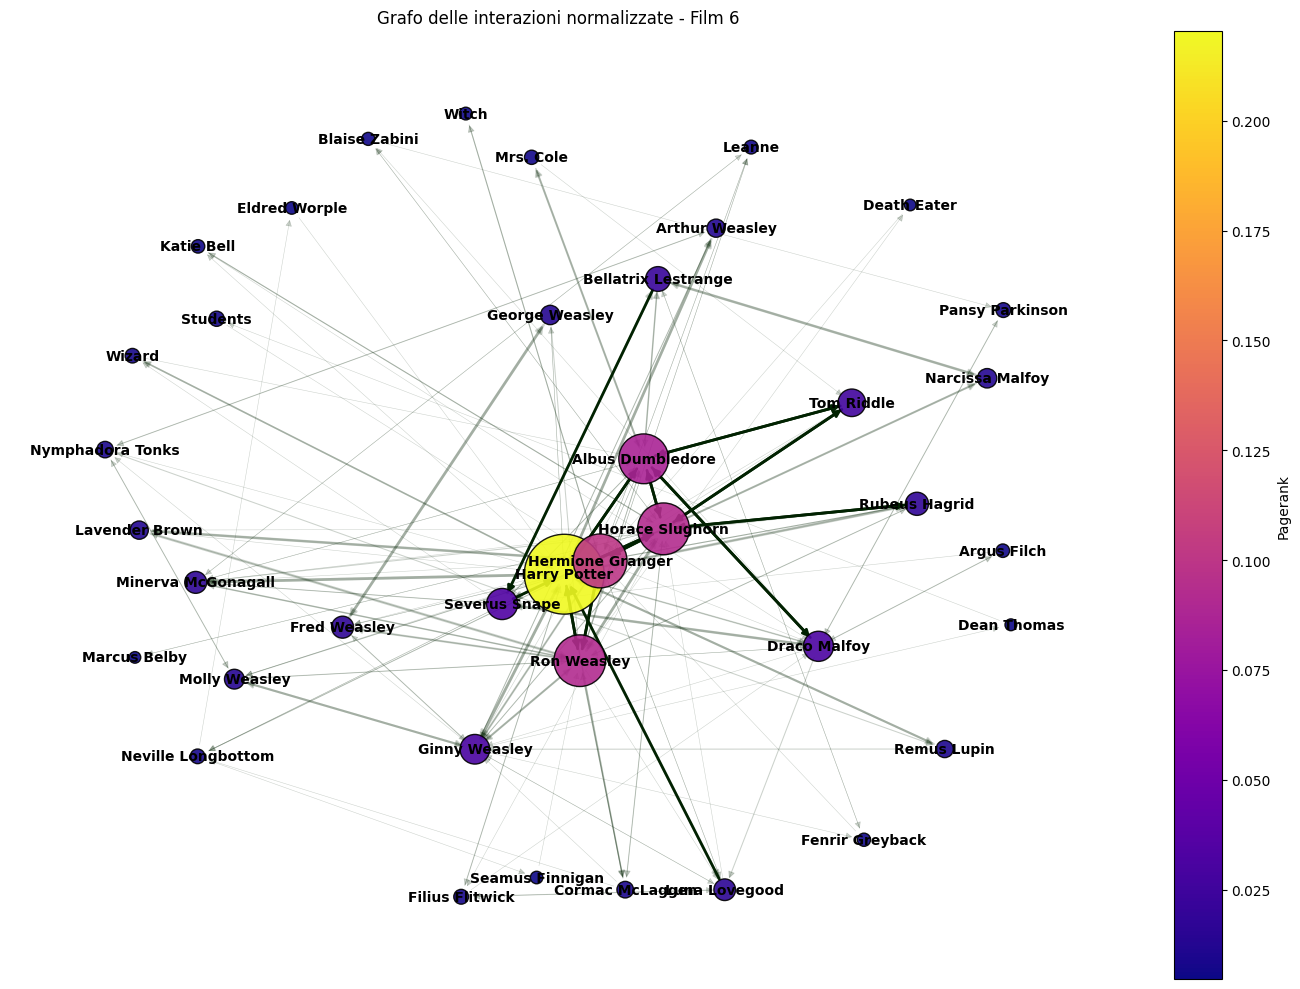

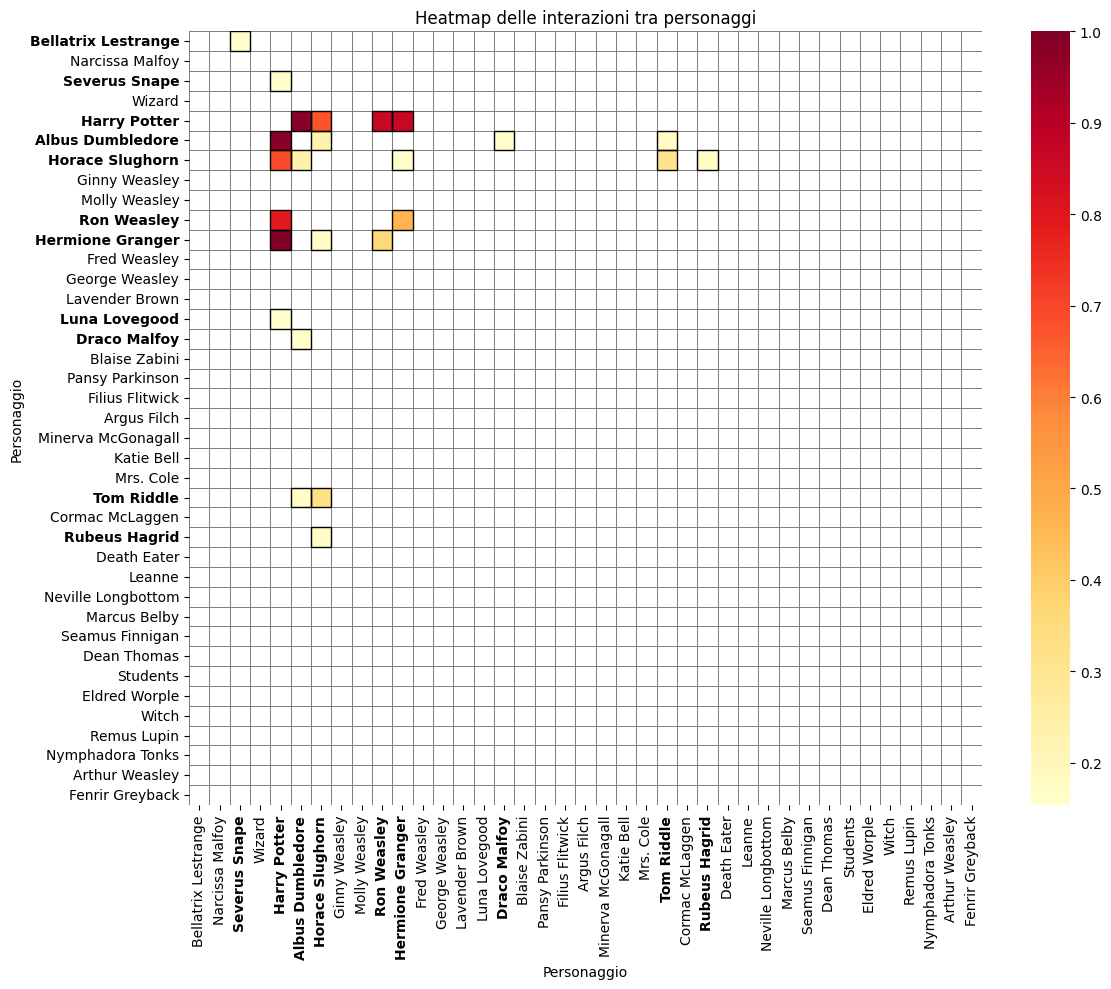

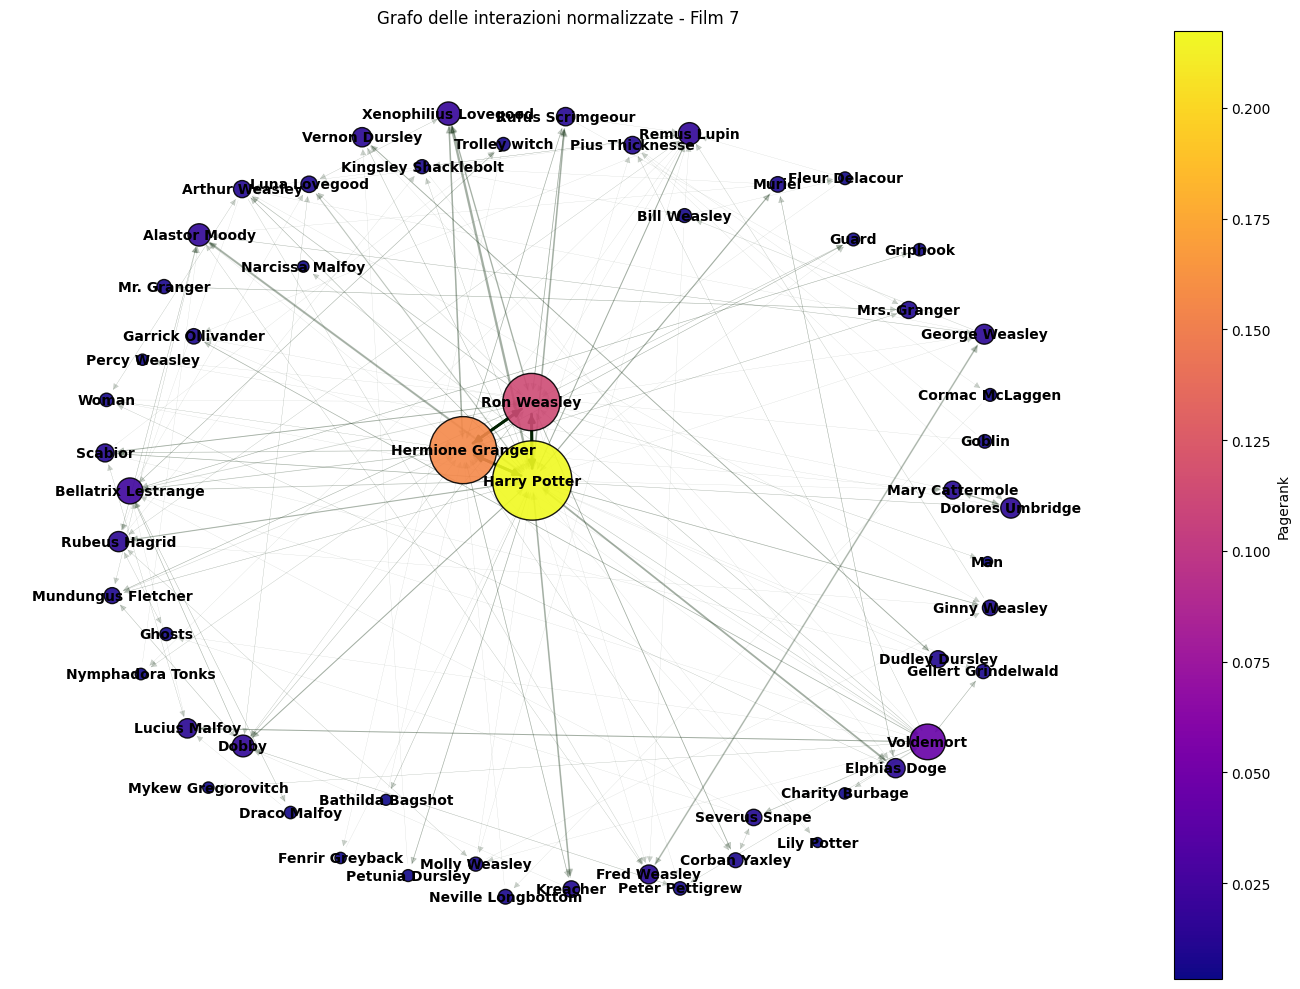

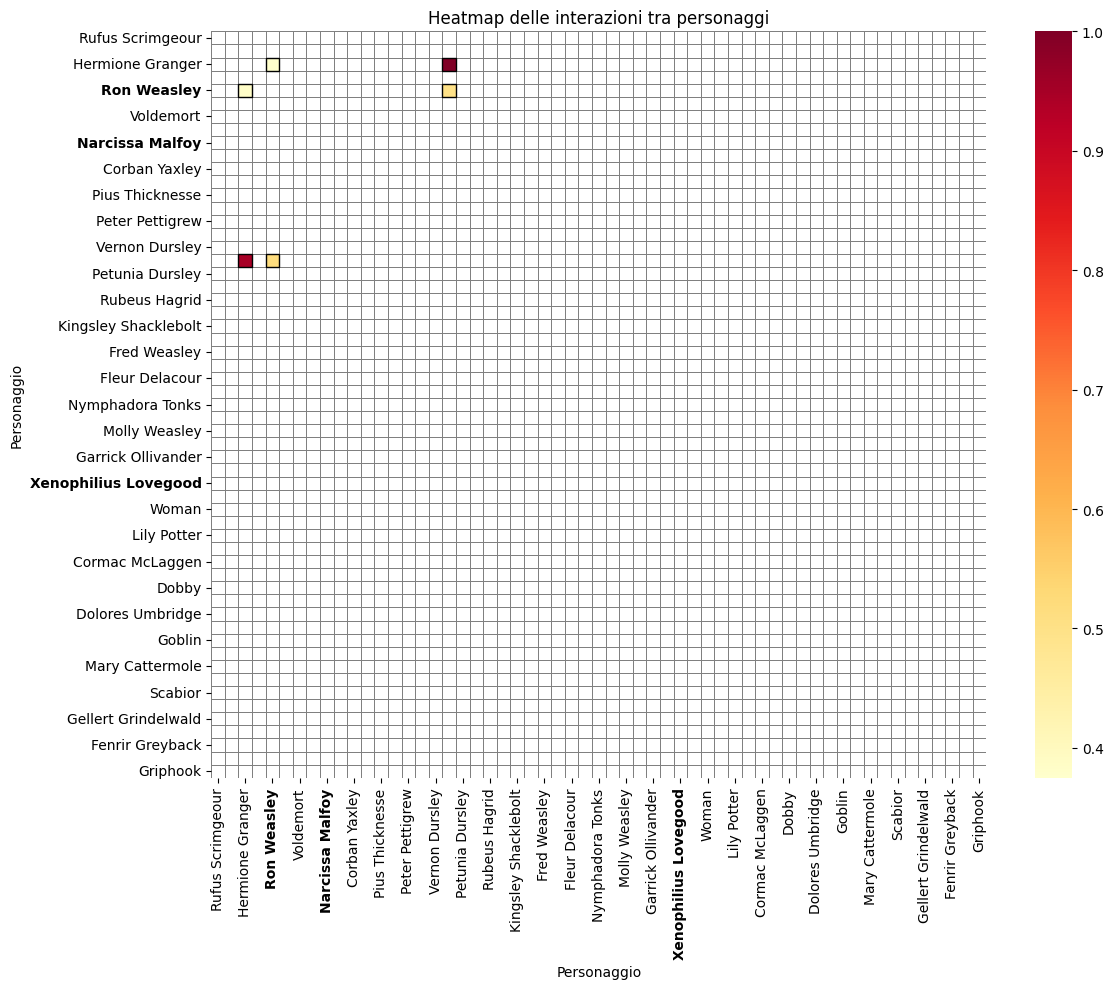

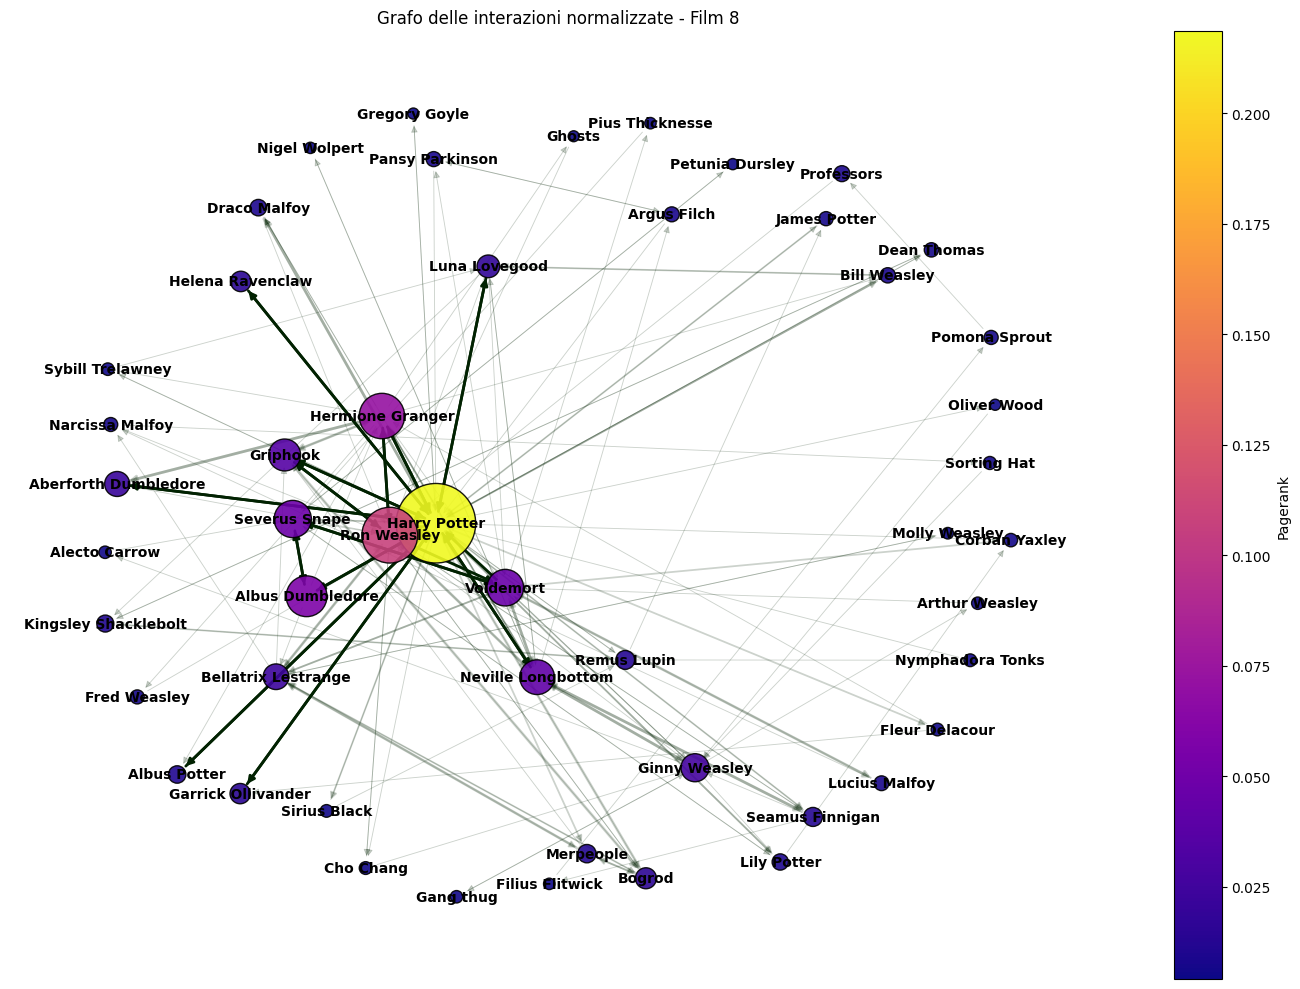

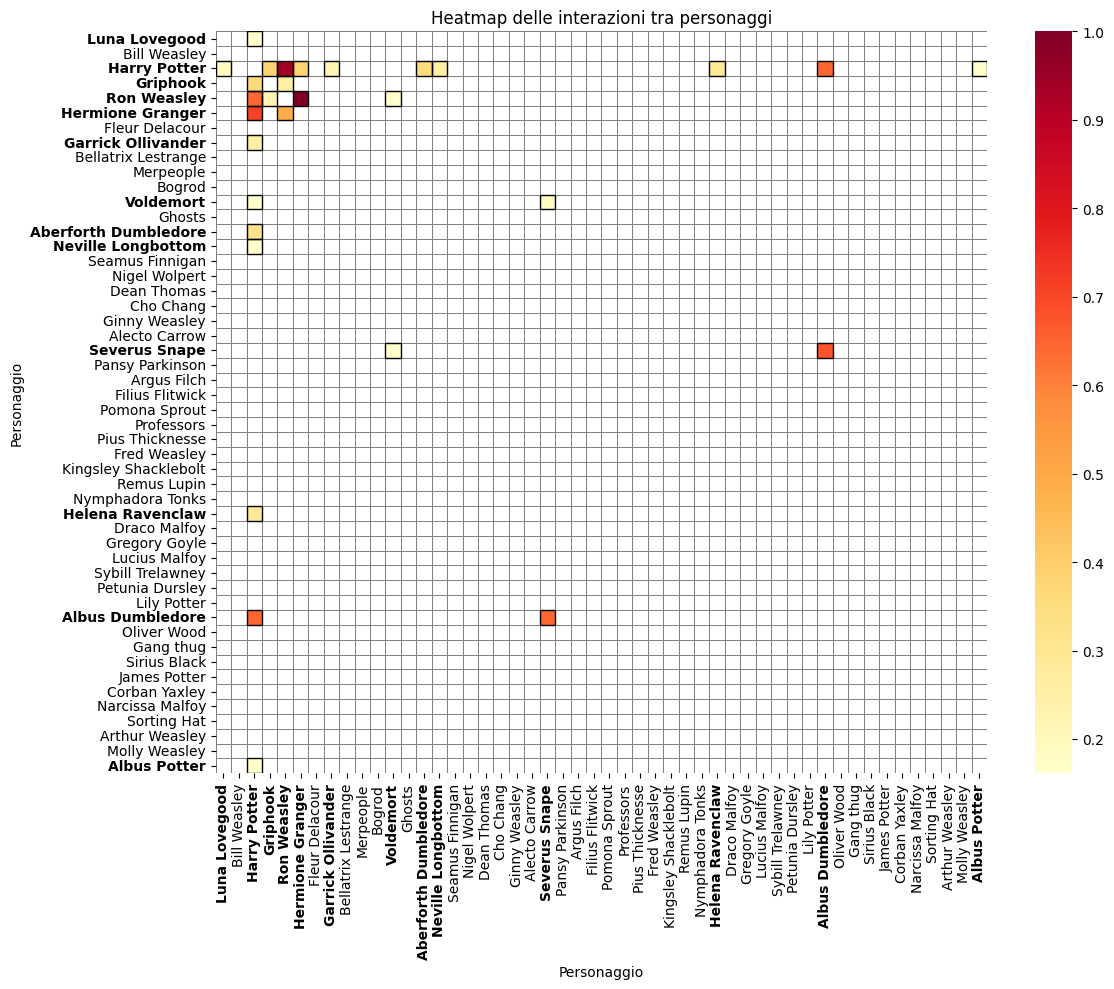

In [392]:
for i in range(1, 9):
  study_film(i, threshold=0.15) # giocare con la soglia di taglio

In [393]:
!pip install transformers
!pip install -q networkx pandas matplotlib

# Parte 3

In questa parte intendiamo fare un'analisi sullo stile emotivo dei personaggi usando la casata di appartenenza come criterio di suddivisione. Perciò isoliamo i personaggi, rappresentiamoli nuovamente su grafi opportunamente divisi e usiamo nuovamente transformers/lexicon/altro e cerchiamo se esistono dei pattern.

In [394]:
dialogues

,Dialogue ID,Chapter ID,Place ID,Character ID,Dialogue
0,1,1,8,4,I should have known that you would be here...P...
1,2,1,8,7,"Good evening, Professor Dumbledore. Are the ru..."
2,3,1,8,4,"I'm afraid so, Professor. The good, and the bad."
3,4,1,8,7,And the boy?
4,5,1,8,4,Hagrid is bringing him.
...,...,...,...,...,...
7439,7440,234,71,1,Then Slytherin House will have gained a wonder...
7440,7441,234,71,84,Really?
7441,7442,234,71,1,Really.
7442,7443,234,71,1,Ready?


In [395]:
characters

,Character ID,Character Name,Species,Gender,House,Patronus,Wand (Wood),Wand (Core)
0,1,Harry Potter,Human,Male,Gryffindor,Stag,Holly,Phoenix Feather
1,2,Ron Weasley,Human,Male,Gryffindor,Jack Russell Terrier,NaN,NaN
2,3,Hermione Granger,Human,Female,Gryffindor,Otter,Vine,Dragon Heartstring
3,4,Albus Dumbledore,Human,Male,Gryffindor,Phoenix,Elder,Thestral Tail Hair
4,5,Rubeus Hagrid,Half-Human/Half-Giant,Male,Gryffindor,NaN,Oak,NaN
...,...,...,...,...,...,...,...,...
161,162,Waiter,NaN,NaN,NaN,NaN,NaN,NaN
162,163,Boy 2,NaN,NaN,NaN,NaN,NaN,NaN
163,164,Crowd,NaN,NaN,NaN,NaN,NaN,NaN
164,165,Gryffindors,NaN,NaN,NaN,NaN,NaN,NaN


In [396]:
# mergiamo dialogues con characters 
dialogues = dialogues.merge(characters, on="Character ID")

# eliminiamo le colonne che non ci servono
full_saga_df = dialogues.drop(columns=['Dialogue ID', 'Place ID', 'Patronus', 'Wand (Wood)', 'Wand (Core)'], errors='ignore')

full_saga_df

,Chapter ID,Character ID,Dialogue,Character Name,Species,Gender,House
0,1,4,I should have known that you would be here...P...,Albus Dumbledore,Human,Male,Gryffindor
1,1,7,"Good evening, Professor Dumbledore. Are the ru...",Minerva McGonagall,Human,Female,Gryffindor
2,1,4,"I'm afraid so, Professor. The good, and the bad.",Albus Dumbledore,Human,Male,Gryffindor
3,1,7,And the boy?,Minerva McGonagall,Human,Female,Gryffindor
4,1,4,Hagrid is bringing him.,Albus Dumbledore,Human,Male,Gryffindor
...,...,...,...,...,...,...,...
7439,234,1,Then Slytherin House will have gained a wonder...,Harry Potter,Human,Male,Gryffindor
7440,234,84,Really?,Albus Potter,Human,Male,Slytherin
7441,234,1,Really.,Harry Potter,Human,Male,Gryffindor
7442,234,1,Ready?,Harry Potter,Human,Male,Gryffindor


In [397]:
# ora creiamo un grafo come in precedenza però sul dataset full_saga_df in modo da fare valutazioni "globali"
G = nx.DiGraph()
# Lista dei turni parlati
speakers = full_saga_df["Character Name"].tolist()
# Costruisci coppie consecutive A→B
pairs = [(a, b) for a, b in zip(speakers[:-1], speakers[1:]) if a != b]
# Conta interazioni tra ogni coppia
interaction_count = defaultdict(int)
interlocutors = defaultdict(set)
for a, b in pairs:
    interaction_count[(a, b)] += 1
    interlocutors[a].add(b)
max_count = max(interaction_count.values())
# Calcola somma delle interazioni per ogni A (normalizzazione per A)
for (a, b), count in interaction_count.items():
    norm_weight = count / max_count
    G.add_edge(a, b, weight=norm_weight)

# aggiungiamo l'attributo House ai nodi
for node in G.nodes():
    # Trova la casa del personaggio
    house = full_saga_df[full_saga_df['Character Name'] == node]['House'].values
    if house.size > 0:
        G.nodes[node]['House'] = house[0]
    else:
        G.nodes[node]['House'] = 'Not a Hogwart Student'

# Calcola centralità
betweenness = nx.betweenness_centrality(G, weight="weight")
# Calcolo degree centrality su grafo non orientato temporaneo
G_undirected = G.to_undirected()
degree = nx.degree_centrality(G_undirected)
# Crea DataFrame centralità
centrality_df = pd.DataFrame({
    'Character Name': list(betweenness.keys()),
    'Betweenness': [betweenness[k] for k in betweenness.keys()],
    'Centrality': [degree[k] for k in betweenness.keys()]
})
# Merge con resized_dialogs
resized_dialogs = full_saga_df.merge(centrality_df, on='Character Name', how='left')

degree_c = nx.degree_centrality(G)  # NON usa pesi (opzionale)
in_deg   = G.in_degree(weight="weight")
out_deg  = G.out_degree(weight="weight")
pagerank = nx.pagerank(G, weight="weight")

df_c = pd.DataFrame({
    "character": list(G.nodes),
    "in_degree": [in_deg[n] for n in G.nodes],
    "out_degree": [out_deg[n] for n in G.nodes],
    "pagerank": [pagerank[n] for n in G.nodes],
    "raw_degree": [degree_c[n] for n in G.nodes],
    "movie_id": mid
})

centrality_results[mid] = df_c

centrality_df = pd.concat(centrality_results.values(), ignore_index=True)

In [398]:
def draw_saga_graph(G, cut_threshold, pagerank=None, title="Grafo delle interazioni normalizzate tra personaggi", k=0.6):
    # stampiamo il pesoo degli archi in ordine decrescente
    '''print("Edge weights (sorted):")
    edge_weights = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
    for u, v, d in edge_weights:
        print(f"{u} → {v}: {d['weight']:.2f}")'''

    if pagerank is None:
        pagerank = nx.pagerank(G, weight='weight')

    pos = nx.spring_layout(G, seed=42, k=0.3)
    fig, ax = plt.subplots(figsize=(14, 10))


    node_sizes = [5000 * np.sqrt(pagerank[n]) for n in G.nodes()]
    edge_sizes = [20 * G[u][v]['weight'] for u, v in G.edges()]
    # impostiamo una edge size massima per evitare che le linee siano troppo spesse
    max_edge_size = 2
    edge_sizes = [min(size, max_edge_size) for size in edge_sizes]
    # Normalizziamo i colori dei nodi in base al pagerank
    #node_colors = [pagerank[n] for n in G.nodes()]
    # coloriamo i nodi in base all'attributo 'House' se presente, altrimenti bianco
    node_colors = []
    for n in G.nodes():
        if 'House' in G.nodes[n]:
            house = G.nodes[n]['House']
            if house == 'Gryffindor':
                node_colors.append('#a6332e')
            elif house == 'Hufflepuff':
                node_colors.append('#efbc2f')
            elif house == 'Ravenclaw':
                node_colors.append('#3c4e91')
            elif house == 'Slytherin':
                node_colors.append('#366447')
            else:
                node_colors.append('#FFFFFF')




    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)} # pesi delle interazioni, per ora le conserviamo e basta
    # creiamo degli alfa per gli archi variabili in base al peso dell'arco in modo che siano =0.2 se il loro peso è sotto il threshold, altrimenti =1

    edge_alphas = [0.2 if G[u][v]['weight'] < cut_threshold else 1 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, edgecolors='black', ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_sizes, alpha=edge_alphas, arrows=True, edge_color='#012201', ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='black', ax=ax)
    #nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='black', font_size=8, ax=ax)


    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # mostriamo edge_labels_df in ordine decrescente per peso
    edge_labels_df = pd.DataFrame(edge_labels.items(), columns=['Edge', 'Weight'])
    edge_labels_df = edge_labels_df.sort_values(by='Weight', ascending=False)
    #print("Edge labels (sorted by weight):")
    #print(edge_labels_df.head(10))


In [399]:
def study_saga(threshold):
  pagerank = nx.pagerank(G, weight="weight")  
  draw_saga_graph(G, threshold, pagerank=pagerank, title="Grafo delle interazioni normalizzate - Saga Completa", k=0.2)
  betweenness = nx.betweenness_centrality(G, weight='weight')
  degree = nx.degree_centrality(G)

  adj_matrix = nx.to_pandas_adjacency(G, weight='weight')

  centrality_df = pd.DataFrame({
      "Character Name": list(G.nodes()),
      "Betweenness": [betweenness[n] for n in G.nodes()],
      "Degree": [degree[n] for n in G.nodes()]
  })

  #draw_heatmap(adj_matrix, threshold)
  #print(centrality_df)

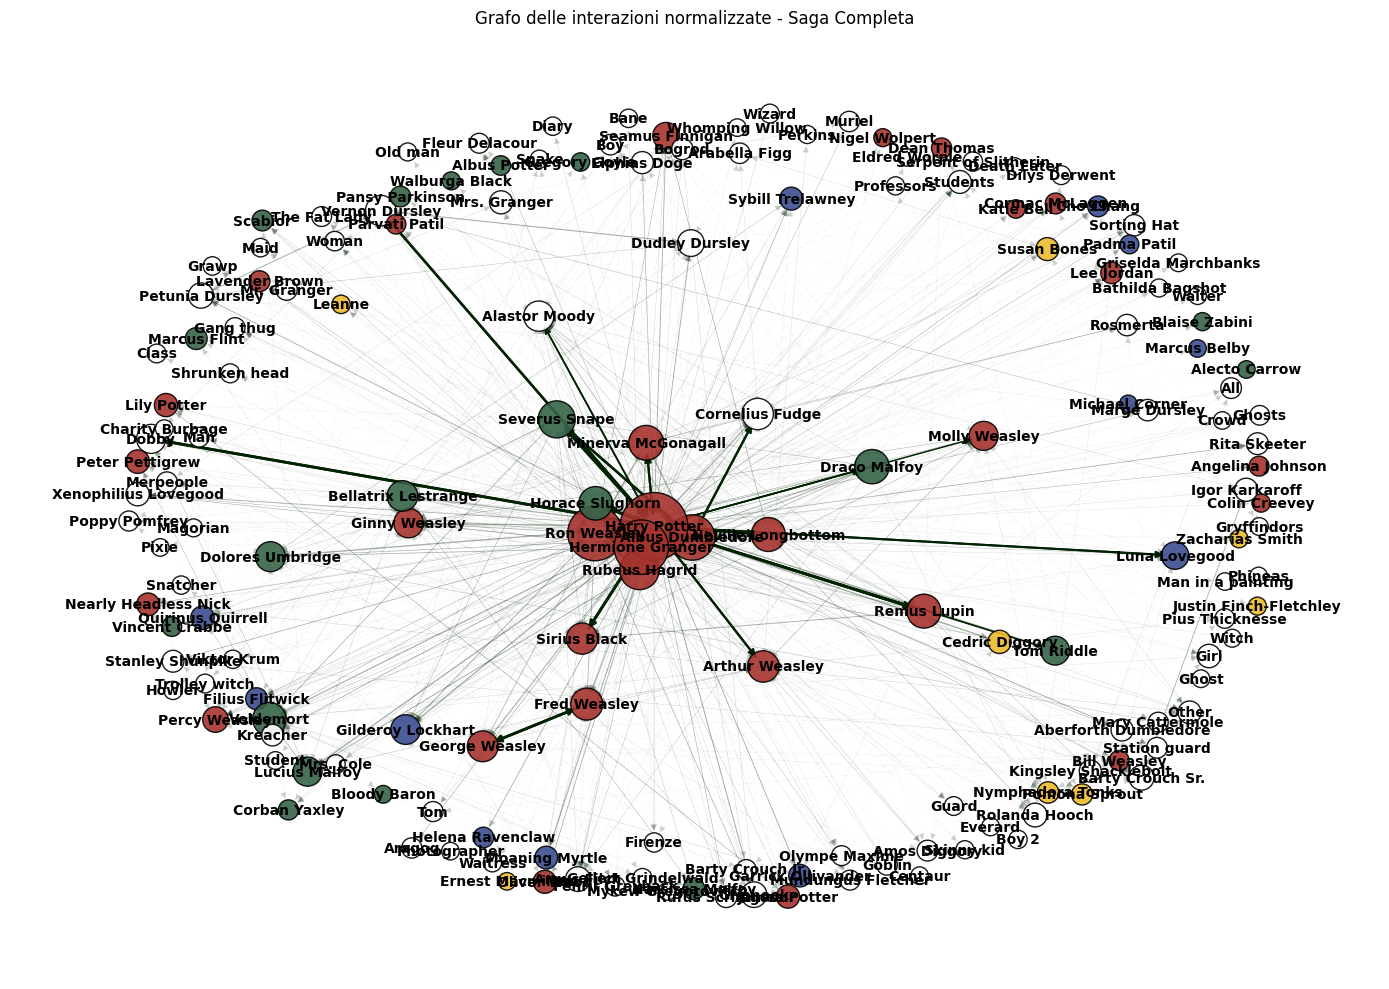

In [400]:
study_saga(threshold=0.05)  # giocare con la soglia di taglio

In [401]:
gryffindor = full_saga_df[full_saga_df['House'] == 'Gryffindor']
hufflepuff = full_saga_df[full_saga_df['House'] == 'Hufflepuff']
ravenclaw = full_saga_df[full_saga_df['House'] == 'Ravenclaw']      
slytherin = full_saga_df[full_saga_df['House'] == 'Slytherin']
others = full_saga_df[~full_saga_df['House'].isin(['Gryffindor', 'Hufflepuff', 'Ravenclaw', 'Slytherin'])]

gryffindor

,Chapter ID,Character ID,Dialogue,Character Name,Species,Gender,House
0,1,4,I should have known that you would be here...P...,Albus Dumbledore,Human,Male,Gryffindor
1,1,7,"Good evening, Professor Dumbledore. Are the ru...",Minerva McGonagall,Human,Female,Gryffindor
2,1,4,"I'm afraid so, Professor. The good, and the bad.",Albus Dumbledore,Human,Male,Gryffindor
3,1,7,And the boy?,Minerva McGonagall,Human,Female,Gryffindor
4,1,4,Hagrid is bringing him.,Albus Dumbledore,Human,Male,Gryffindor
...,...,...,...,...,...,...,...
7435,234,1,Yes?,Harry Potter,Human,Male,Gryffindor
7437,234,1,Albus Severus Potter. You were named after two...,Harry Potter,Human,Male,Gryffindor
7439,234,1,Then Slytherin House will have gained a wonder...,Harry Potter,Human,Male,Gryffindor
7441,234,1,Really.,Harry Potter,Human,Male,Gryffindor


In [402]:
# estriamo i personaggi per casa
houses = {
    'Gryffindor': gryffindor,
    'Hufflepuff': hufflepuff,
    'Ravenclaw': ravenclaw,
    'Slytherin': slytherin
}
gryffindor_characters = gryffindor['Character Name'].unique().tolist()
hufflepuff_characters = hufflepuff['Character Name'].unique().tolist()
ravenclaw_characters = ravenclaw['Character Name'].unique().tolist()
slytherin_characters = slytherin['Character Name'].unique().tolist()
others_characters = others['Character Name'].unique().tolist()

gryffindor_characters

['Albus Dumbledore',
 'Minerva McGonagall',
 'Rubeus Hagrid',
 'Harry Potter',
 'Molly Weasley',
 'George Weasley',
 'Fred Weasley',
 'Ginny Weasley',
 'Ron Weasley',
 'Hermione Granger',
 'Neville Longbottom',
 'Seamus Finnigan',
 'Percy Weasley',
 'Nearly Headless Nick',
 'Oliver Wood',
 'Lee Jordan',
 'Arthur Weasley',
 'Colin Creevey',
 'Dean Thomas',
 'Remus Lupin',
 'Parvati Patil',
 'Sirius Black',
 'Peter Pettigrew',
 'Nigel Wolpert',
 'James Potter',
 'Lily Potter',
 'Angelina Johnson',
 'Lavender Brown',
 'Katie Bell',
 'Cormac McLaggen',
 'Bill Weasley']

### 3.1 Transformers: sentiment analysis sulle casate con Roberta

Usiamo bhadresh-savani/roberta-base-emotion.
Gestisce bene le parole "inventate" ed è un ottimo modello per il task di sentiment analysis. 

Step 1: verifico la lunghezza dei dialoghi

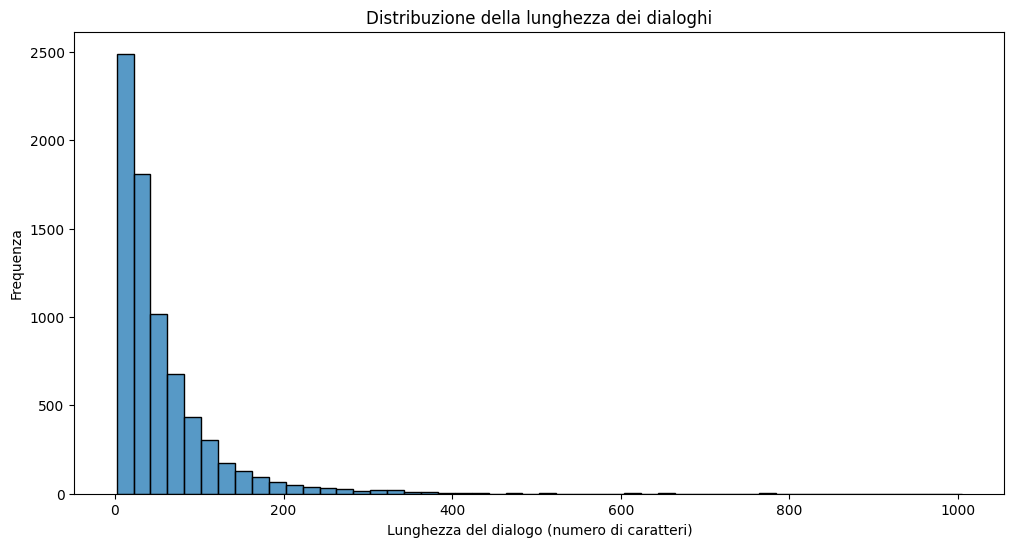

In [403]:
# controlliamo quanto sono lunghi tutti i dialoghi e plotttiamo la distribuzione
full_saga_df['Dialogue Length'] = full_saga_df['Dialogue'].apply(lambda x: len(x))
plt.figure(figsize=(12, 6))
sns.histplot(full_saga_df['Dialogue Length'], bins=50)
plt.title('Distribuzione della lunghezza dei dialoghi')
plt.xlabel('Lunghezza del dialogo (numero di caratteri)')
plt.ylabel('Frequenza')
plt.show()

In [404]:
full_saga_df

,Chapter ID,Character ID,Dialogue,Character Name,Species,Gender,House,Dialogue Length
0,1,4,I should have known that you would be here...P...,Albus Dumbledore,Human,Male,Gryffindor,66
1,1,7,"Good evening, Professor Dumbledore. Are the ru...",Minerva McGonagall,Human,Female,Gryffindor,64
2,1,4,"I'm afraid so, Professor. The good, and the bad.",Albus Dumbledore,Human,Male,Gryffindor,48
3,1,7,And the boy?,Minerva McGonagall,Human,Female,Gryffindor,12
4,1,4,Hagrid is bringing him.,Albus Dumbledore,Human,Male,Gryffindor,23
...,...,...,...,...,...,...,...,...
7439,234,1,Then Slytherin House will have gained a wonder...,Harry Potter,Human,Male,Gryffindor,172
7440,234,84,Really?,Albus Potter,Human,Male,Slytherin,7
7441,234,1,Really.,Harry Potter,Human,Male,Gryffindor,7
7442,234,1,Ready?,Harry Potter,Human,Male,Gryffindor,6


In [405]:
full_saga_df['Dialogue Length'].describe()

count    7444.000000
mean       55.395621
std        65.537972
min         2.000000
25%        17.000000
50%        34.000000
75%        69.000000
max      1005.000000
Name: Dialogue Length, dtype: float64

Dato che la massima lunghezza è di 512 tokens, dobbiamo decidere come agire: scartare tutte le frase sopra una certa lunghezza? Aggiungiamo padding alle frasi corte e tronchiamo quelle lunghe. Data la distribuzione delle frasi possiamo scegliere come fixed lenght anche meno di 512. 

In [406]:
model_name = 'bhadresh-savani/roberta-base-emotion'
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = TFAutoModelForSequenceClassification.from_pretrained(model_name, force_download=True,)
max_tokens_length = 256

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFRobertaForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


In [407]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(model_name)
print(model.config)
print(config.num_labels)  
print(config.id2label)    


RobertaConfig {
  "architectures": [
    "RobertaForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "sadness",
    "1": "joy",
    "2": "love",
    "3": "anger",
    "4": "fear",
    "5": "surprise"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "anger": 3,
    "fear": 4,
    "joy": 1,
    "love": 2,
    "sadness": 0,
    "surprise": 5
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classification",
  "transformers_version": "4.52.4",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 50265
}

6
{0: 'sadness', 1: 'joy', 2: 'l

Iniziamo il task di sentiment prediction. Con Roberta facciamo l'encoding dei dialoghi e chiediamo al modello di fare la previsione del sentimento. Ci sono 6 possibili emozioni prevedibili .

In [408]:
# funzione per il calcolo delle emozioni per ogni dialogo. Al modello viene chiesto di tokenizzare ogni sequenza aggiungendo 
# il padding per le sequenze brevi e troncando le sequenze più lunghe di 256 caratteri. Questo numero è stato scelto perchè
# i dialoghi sopra questa lunghezza sono molto rari. 
# Infine applicando la funzione softmax ai logits calcolati e otteniamo la stima delle emozioni.

def calculate_emotion_score(dialogues, tokenizer, max_length=256):
    predictions = []

    for dialogue in tqdm(dialogues, desc="Processing dialogues", total=len(dialogues)):
        encoded = tokenizer.encode_plus(
            dialogue,
            add_special_tokens=True,
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_tensors='tf'
        )

        logits = model(**encoded).logits
        probs = tf.nn.softmax(logits, axis=-1).numpy()[0]
        predictions.append(probs)
        
    return np.array(predictions)


La seguente cella chiama la funzione per il calcolo delle emozioni sull'intero set di copioni ed è discretamente oneroso. Per questo motivo il risultato verrà esportato in csv e all'occorrenza caricato.

In [409]:
#emotions_scores = calculate_emotion_score(full_saga_df['Dialogue'], tokenizer, max_length=max_tokens_length)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Aggiungiamo le emozioni al DataFrame
#emotions_df = pd.DataFrame(emotions_scores, columns=labels)

# Aggiungiamo le emozioni al DataFrame principale
#full_saga_df = pd.concat([full_saga_df, emotions_df], axis=1)

# esportiamo in CSV
#full_saga_df.to_csv("full_saga_with_emotions.csv", index=False, encoding='utf-8-sig')

In [410]:
# importiamo il CSV
full_saga_df = pd.read_csv("full_saga_with_emotions.csv", encoding='utf-8-sig')
emotions_df = full_saga_df[labels]
emotions_df

,sadness,joy,love,anger,fear,surprise
0,0.023260,0.388861,0.016448,0.349737,0.216222,0.005472
1,0.011105,0.173946,0.006061,0.124526,0.679201,0.005161
2,0.004121,0.009718,0.001972,0.024115,0.958835,0.001239
3,0.005385,0.044380,0.003079,0.813943,0.130882,0.002331
4,0.017564,0.307261,0.009926,0.551603,0.110248,0.003397
...,...,...,...,...,...,...
7439,0.000840,0.992225,0.004920,0.000989,0.000658,0.000368
7440,0.006042,0.053356,0.001996,0.889190,0.040082,0.009334
7441,0.013155,0.211541,0.004121,0.722299,0.046243,0.002640
7442,0.001087,0.976710,0.003200,0.008079,0.010463,0.000463


#### Visualizzazione risultati

1. studiamo le statistiche del dataset.

In [411]:
# studiamo emotions_df
emotions_df.describe()

,sadness,joy,love,anger,fear,surprise
count,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000,7444.000000
mean,0.048865,0.444715,0.012836,0.398621,0.089899,0.005064
std,0.146519,0.348195,0.054547,0.334221,0.159668,0.039987
min,0.000156,0.000426,0.000137,0.000174,0.000225,0.000114
25%,0.005611,0.107601,0.003048,0.074814,0.010306,0.001149
50%,0.013003,0.387874,0.006198,0.330721,0.032945,0.001990
75%,0.027848,0.791092,0.010758,0.707077,0.086667,0.003145
max,0.998022,0.998693,0.991453,0.997033,0.994943,0.979688


2. sommiamo le colonne delle emozioni e visualizziamole

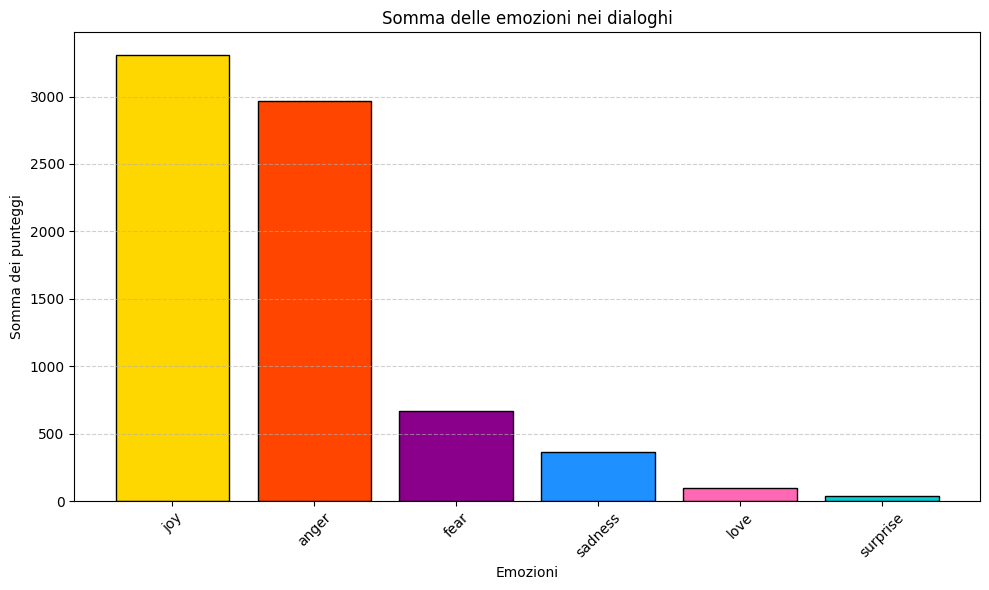

In [412]:
# Somma delle emozioni
emotion_sums = emotions_df.sum().sort_values(ascending=False)

emotion_colors = {
    'joy': '#FFD700',        
    'sadness': '#1E90FF',    
    'anger': '#FF4500',      
    'fear': '#8B008B',       
    'surprise': '#00CED1',   
    'love': '#FF69B4',       
    'optimism': '#32CD32'    
}

# Ordinamento coerente
colors = [emotion_colors[emotion] for emotion in emotion_sums.index]

# Creazione grafico
plt.figure(figsize=(10, 6))
plt.bar(emotion_sums.index, emotion_sums.values, color=colors, edgecolor='black')

plt.title("Somma delle emozioni nei dialoghi")
plt.ylabel("Somma dei punteggi")
plt.xlabel("Emozioni")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


3. facciamo un distinguo basato sulle casate con diversi grafici.

,sadness,joy,love,anger,fear,surprise
House,,,,,,
Gryffindor,251.647847,2364.231505,61.517332,2177.529074,489.118355,24.955874
Hufflepuff,2.368852,27.884928,1.042093,21.149899,3.424062,0.130166
Ravenclaw,20.306361,109.675957,3.439131,64.119724,22.701022,1.757805
Slytherin,43.957685,389.517025,13.673900,333.818549,73.813899,5.218942


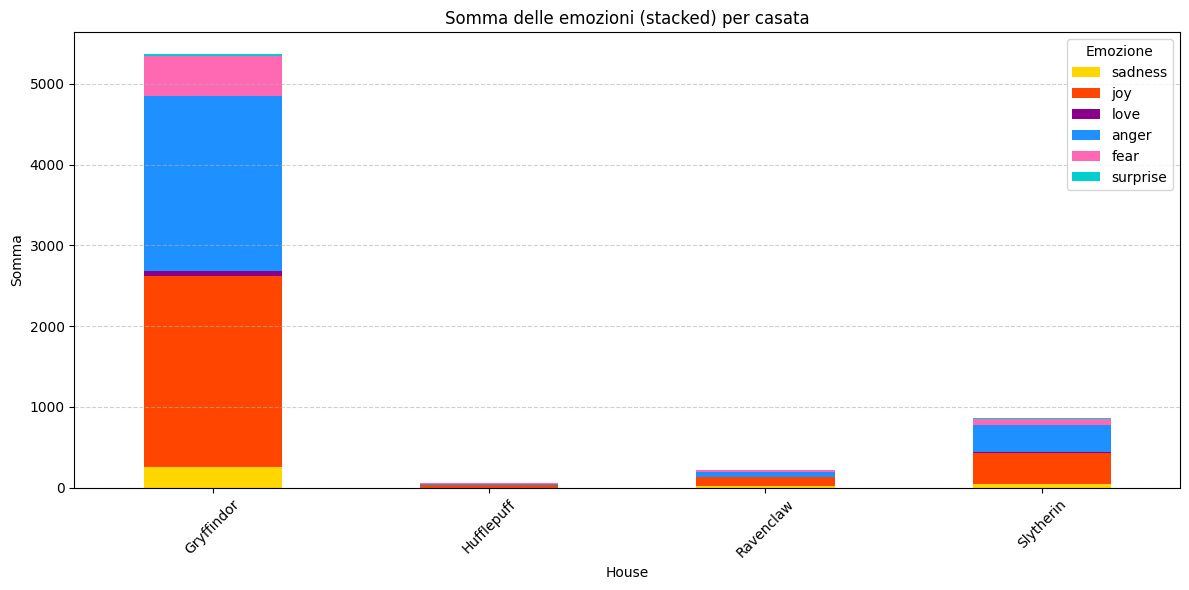

In [413]:
# adesso facciamo un altro grafico a barre con la somma delle emozioni, ma questa volta includiamo la suddivisione per case
gryffindor = full_saga_df[full_saga_df['House'] == 'Gryffindor']
hufflepuff = full_saga_df[full_saga_df['House'] == 'Hufflepuff']
ravenclaw = full_saga_df[full_saga_df['House'] == 'Ravenclaw']      
slytherin = full_saga_df[full_saga_df['House'] == 'Slytherin']
others = full_saga_df[~full_saga_df['House'].isin(['Gryffindor', 'Hufflepuff', 'Ravenclaw', 'Slytherin'])]

# Raggruppa e riordina le emozioni per colore (opzionale)
house_emotion_sums = full_saga_df.groupby('House').sum()  # transponi: emozioni per riga
house_emotion_sums = house_emotion_sums[labels]
house_emotion_sums.drop(['Beauxbatons Academy of Magic', 'Durmstrang Institute'], inplace=True)

# Colori per ogni casata
house_colors = {
    'Gryffindor': '#9C1F1F',
    'Hufflepuff': '#F0C330',
    'Ravenclaw': '#0E4C92',
    'Slytherin': '#1A472A',
    'Altri': '#999999'  # per personaggi senza casata
}

display(house_emotion_sums)


# Creazione grafico
house_emotion_sums.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)

plt.title("Somma delle emozioni (stacked) per casata")
plt.ylabel("Somma")
plt.xticks(rotation=45)
plt.legend(title="Emozione")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Abbiamo il problema dello sbilanciamento. Passiamo comunque intanto da una visualizzazione assoluta ad una relativa

In [414]:
relative_house_emotions = house_emotion_sums.apply(lambda row: row / row.sum(), axis=1)


relative_house_emotions

,sadness,joy,love,anger,fear,surprise
House,,,,,,
Gryffindor,0.046871,0.440349,0.011458,0.405574,0.091100,0.004648
Hufflepuff,0.042301,0.497945,0.018609,0.377677,0.061144,0.002324
Ravenclaw,0.091470,0.494036,0.015492,0.288828,0.102257,0.007918
Slytherin,0.051114,0.452927,0.015900,0.388161,0.085830,0.006069


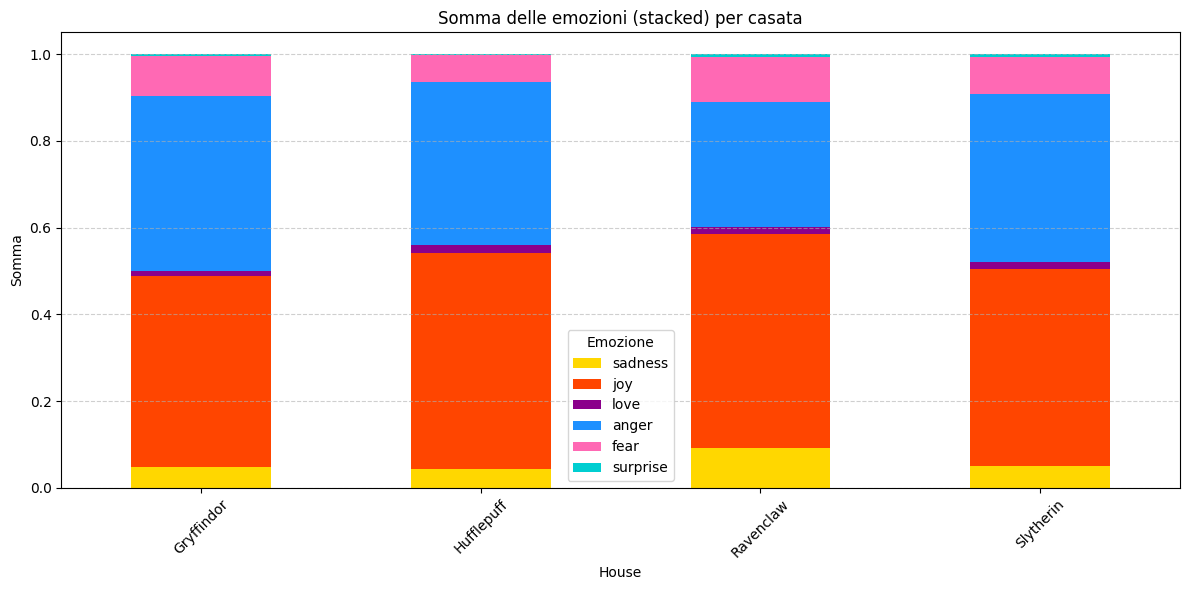

In [415]:
# Creazione grafico
relative_house_emotions.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors)

plt.title("Somma delle emozioni (stacked) per casata")
plt.ylabel("Somma")
plt.xticks(rotation=45)
plt.legend(title="Emozione")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Tentiamo anche una visualizzazione su boxplot sui valori originali forniti dal transformer non normalizzati

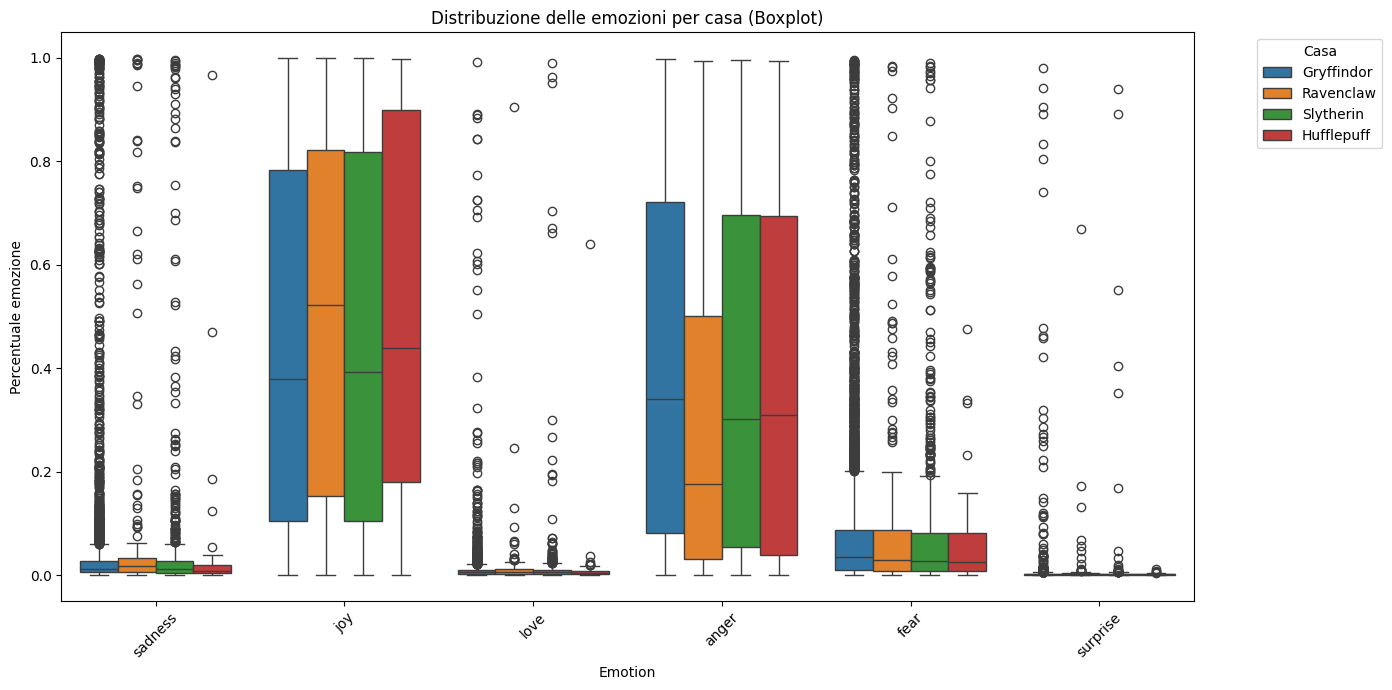

In [416]:

# Supponiamo che le tue colonne emozioni si chiamino così:
emotion_cols = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
df_filtered = full_saga_df[~full_saga_df['House'].isin(['Beauxbatons Academy of Magic', 'Durmstrang Institute'])]

# Passaggio 1: melt per fare il DataFrame "long"
df_long = pd.melt(df_filtered,
                  id_vars=['House'],    # mantieni questa colonna fissa
                  value_vars=emotion_cols,  # colonne da trasformare in riga
                  var_name='Emotion',
                  value_name='Score')

# Passaggio 2: plot boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_long, x='Emotion', y='Score', hue='House')

plt.title("Distribuzione delle emozioni per casa (Boxplot)")
plt.ylabel("Percentuale emozione")
plt.xticks(rotation=45)
plt.legend(title='Casa', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Non pare emergere un particolare pattern che metta in evidenza il rapporto tra la casa e l'emozione dominante.
#### Conclusione
A causa del problema dello sbilanciamento e dell'assenza di pattern si può concludere che non è una buona idea fare una campagna di merketing di merchandising delle case basato sulla emozioni.

### 3.2 Approccio con i Lexicon
Proviamo ora invece un approccio più tradizionale